# **1. Import Libraries & Data**

In [1]:
# Core & Utility Libraries
import os
import random
import warnings
import gdown

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import squarify
%matplotlib inline

# Scikit-Learn: Preprocessing & Encoders
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, OrdinalEncoder, FunctionTransformer, 
                                   LabelEncoder, MinMaxScaler)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# Scikit-Learn: Model Selection
from sklearn.model_selection import (train_test_split, GridSearchCV, cross_val_score, 
                                     cross_val_predict, StratifiedKFold)

# Scikit-Learn: Models
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (IsolationForest, StackingClassifier, 
                              HistGradientBoostingClassifier)
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import (make_scorer, accuracy_score, classification_report, 
                             f1_score)

# Boosting Libraries
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMRegressor
from catboost import CatBoostClassifier, Pool

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# Optimization
import optuna

# --- Configuration & Setup ---

# Ignore Warnings
warnings.filterwarnings("ignore")

# Pandas Display Options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set Seaborn Color Palette
colors = ['#1c76b6', '#a7dae9', '#eb6a20', '#f59d3d', '#677fa0', '#d6e4ed', '#f7e9e5']
sns.set_palette(colors)

In [2]:
def create_gdrive_download_link(sharing_link: str) -> str:
    try:
        file_id = sharing_link.split('/d/')[1].split('/')[0]
        download_link = f'https://drive.google.com/uc?export=download&id={file_id}'
        return download_link
    except IndexError:
        return "Error: The provided URL does not seem to be a valid Google Drive sharing link."
    except Exception as e:
        return f"An unexpected error occurred: {e}"

In [3]:
KLAIM_PATH = 'https://drive.google.com/file/d/13hOJ1CZbAqZoNCEWOhWc9rlJu7b9SU0u/view?usp=drive_link'
POLIS_PATH = 'https://drive.google.com/file/d/181WNTQKlaWxJecRc4w3dEPBWJomanXTV/view?usp=drive_link'
SAMPLE_SUB_PATH = 'https://drive.google.com/file/d/1kDUQqaQqypsiRJakn7aIH177KfW6XsTm/view?usp=drive_link'

In [4]:
klaim_prep_link = create_gdrive_download_link(KLAIM_PATH)
polis_prep_link = create_gdrive_download_link(POLIS_PATH)
sample_sub_prep_link = create_gdrive_download_link(SAMPLE_SUB_PATH)

In [5]:
gdown.download(klaim_prep_link, 'klaim.csv', quiet=False)
gdown.download(polis_prep_link, 'polis.csv', quiet=False)
gdown.download(sample_sub_prep_link, 'sample_sub.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?export=download&id=13hOJ1CZbAqZoNCEWOhWc9rlJu7b9SU0u
To: /kaggle/working/klaim.csv
100%|██████████| 600k/600k [00:00<00:00, 90.9MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=181WNTQKlaWxJecRc4w3dEPBWJomanXTV
To: /kaggle/working/polis.csv
100%|██████████| 183k/183k [00:00<00:00, 72.2MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=1kDUQqaQqypsiRJakn7aIH177KfW6XsTm
To: /kaggle/working/sample_sub.csv
100%|██████████| 390/390 [00:00<00:00, 1.37MB/s]


'sample_sub.csv'

In [6]:
df_klaim = pd.read_csv('klaim.csv', encoding="utf-8")
df_polis = pd.read_csv('polis.csv', encoding="utf-8")
sample_sub = pd.read_csv('sample_sub.csv', encoding="utf-8")

# **2. Exploratory Data Analysis**

## Gambaran Besar Dataset

In [7]:
pd.concat([df_klaim.head(), df_klaim.tail()])

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,2.809365e+07,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,8.098728e+07,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,1.830471e+08,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,1.914244e+08,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,1.389364e+08,1.389364e+08,Singapore
4622,C-5777-M,POL-3288,C,IP,C34,Malignant neoplasm of bronchus and lung,PAID,2025-07-02,2025-03-11,2025-03-11,1.513929e+07,1.531253e+07,Malaysia
4623,C-5778-M,POL-3288,C,IP,C34,Malignant neoplasm of bronchus and lung,PAID,2025-07-08,2025-04-18,2025-04-18,6.336514e+07,6.620405e+07,Malaysia
4624,C-5779-M,POL-3288,C,IP,C34.1,"Malignant neoplasm of upper lobe, bronchus or ...",PAID,NaN,2025-05-21,2025-05-21,1.632886e+07,1.651873e+07,Malaysia
4625,C-5780-M,POL-3288,C,IP,C34.9,"Malignant neoplasm of bronchus or lung, unspec...",PAID,NaN,2025-06-30,2025-06-30,6.540838e+07,6.662646e+07,Malaysia
4626,C-5781-M,POL-3288,C,IP,C34.1,"Malignant neoplasm of upper lobe, bronchus or ...",PAID,2025-03-12,2025-01-07,2025-01-07,1.538734e+07,1.556434e+07,Malaysia


In [8]:
pd.concat([df_polis.head(), df_polis.tail()])

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA
3,POL-0004,M-003,M,20140724,20160811,JAKARTA
4,POL-0005,M-001,F,19810114,20150828,JAKARTA
4091,POL-4092,M-003,F,19540520,20170518,SURABAYA
4092,POL-4093,M-003,F,19811124,20170811,TANGERANG
4093,POL-4094,M-003,F,20040812,20170721,TANGERANG
4094,POL-4095,M-002,F,19640127,20161221,MANADO
4095,POL-4096,M-003,F,19710914,20171110,JAKARTA


In [9]:
sample_sub

,id,value
0,2025_08_Claim_Frequency,0
1,2025_08_Claim_Severity,0
2,2025_08_Total_Claim,0
3,2025_09_Claim_Frequency,0
4,2025_09_Claim_Severity,0
5,2025_09_Total_Claim,0
6,2025_10_Claim_Frequency,0
7,2025_10_Claim_Severity,0
8,2025_10_Total_Claim,0
9,2025_11_Claim_Frequency,0


In [10]:
print("Ukuran Data Klaim: ", df_klaim.shape)
print("Ukuran Data Polis: ", df_polis.shape)

Ukuran Data Klaim:  (4627, 13)
Ukuran Data Polis:  (4096, 6)


In [11]:
print("Banyak data duplikat:")
print(df_klaim.duplicated().sum())
print(df_polis.duplicated().sum())

Banyak data duplikat:
0
0


In [12]:
print("Banyak Data Hilang Setiap Kolom (Data Klaim):")
print(df_klaim.isnull().sum())

Banyak Data Hilang Setiap Kolom (Data Klaim):
Claim ID                          0
Nomor Polis                       0
Reimburse/Cashless                0
Inpatient/Outpatient             37
ICD Diagnosis                     6
ICD Description                   6
Status Klaim                      0
Tanggal Pembayaran Klaim         37
Tanggal Pasien Masuk RS           0
Tanggal Pasien Keluar RS          0
Nominal Klaim Yang Disetujui      0
Nominal Biaya RS Yang Terjadi     0
Lokasi RS                         7
dtype: int64


In [13]:
print("Banyak Data Hilang Setiap Kolom (Data Polis):")
print(df_polis.isnull().sum())

Banyak Data Hilang Setiap Kolom (Data Polis):
Nomor Polis              0
Plan Code                0
Gender                   0
Tanggal Lahir            0
Tanggal Efektif Polis    0
Domisili                 0
dtype: int64


In [14]:
print("Gambaran Besar Data Klaim:")
df_klaim.info()

Gambaran Besar Data Klaim:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Claim ID                       4627 non-null   object 
 1   Nomor Polis                    4627 non-null   object 
 2   Reimburse/Cashless             4627 non-null   object 
 3   Inpatient/Outpatient           4590 non-null   object 
 4   ICD Diagnosis                  4621 non-null   object 
 5   ICD Description                4621 non-null   object 
 6   Status Klaim                   4627 non-null   object 
 7   Tanggal Pembayaran Klaim       4590 non-null   object 
 8   Tanggal Pasien Masuk RS        4627 non-null   object 
 9   Tanggal Pasien Keluar RS       4627 non-null   object 
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64
 11  Nominal Biaya RS Yang Terjadi  4627 non-null   float64
 12  Lokasi RS            

In [15]:
print("Gambaran Besar Data Polis:")
df_polis.info()

Gambaran Besar Data Polis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nomor Polis            4096 non-null   object
 1   Plan Code              4096 non-null   object
 2   Gender                 4096 non-null   object
 3   Tanggal Lahir          4096 non-null   int64 
 4   Tanggal Efektif Polis  4096 non-null   int64 
 5   Domisili               4096 non-null   object
dtypes: int64(2), object(4)
memory usage: 192.1+ KB


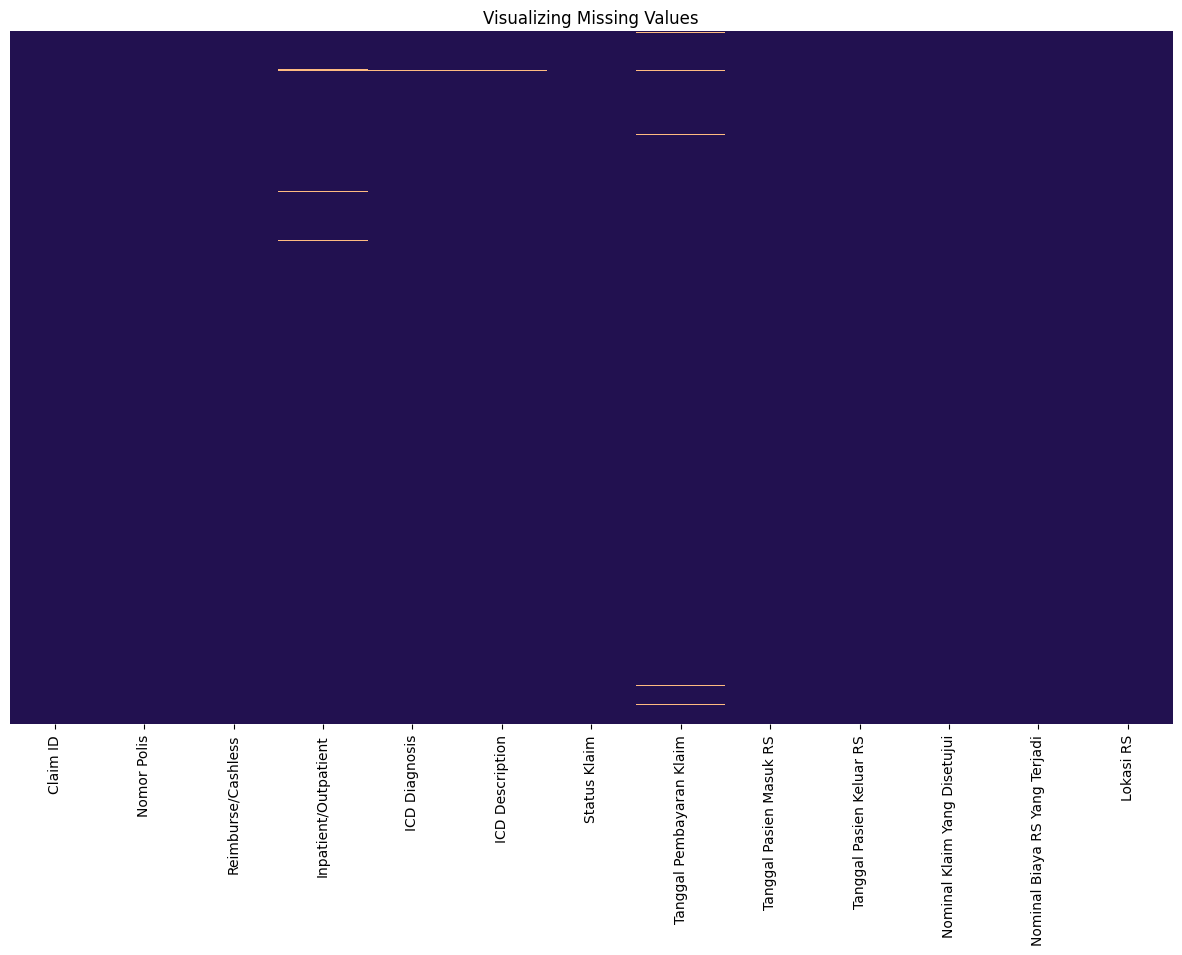

In [16]:
plt.figure(figsize=(15,9))
plt.title("Visualizing Missing Values")
sns.heatmap(df_klaim.isnull(), cbar=False, cmap=sns.color_palette('magma'), yticklabels=False);
plt.show()

## Data Cleansing & FE Awal

In [17]:
import pandas as pd
import numpy as np

def prepare_insurance_data(df_klaim, df_polis):
    # ==========================================
    # 1. FORMATTING TANGGAL (DATE PARSING)
    # ==========================================
    # df_klaim: Format string 'YYYY-MM-DD'
    date_cols_klaim = ['Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS']
    for col in date_cols_klaim:
        df_klaim[col] = pd.to_datetime(df_klaim[col], errors='coerce')
        
    # df_polis: Format integer YYYYMMDD (harus dispesifikasikan formatnya agar cepat dan presisi)
    date_cols_polis = ['Tanggal Lahir', 'Tanggal Efektif Polis']
    for col in date_cols_polis:
        df_polis[col] = pd.to_datetime(df_polis[col], format='%Y%m%d', errors='coerce')

    # ==========================================
    # 2. PENGGABUNGAN DATA (MERGING)
    # ==========================================
    # Kita gunakan LEFT JOIN dari df_klaim agar tidak ada data klaim yang hilang
    df_merged = pd.merge(df_klaim, df_polis, on='Nomor Polis', how='left')

    # ==========================================
    # 3. FEATURE ENGINEERING
    # ==========================================
    # a. Lama Rawat Inap (Length of Stay / LoS) dalam hari
    # Menggunakan np.maximum untuk mencegah nilai negatif jika ada error input data (keluar < masuk)
    df_merged['Lama Rawat Inap'] = (df_merged['Tanggal Pasien Keluar RS'] - df_merged['Tanggal Pasien Masuk RS']).dt.days
    df_merged['Lama Rawat Inap'] = np.maximum(df_merged['Lama Rawat Inap'], 0)

    # b. Usia Pasien saat klaim terjadi (dalam tahun)
    # Dibagi 365.25 untuk mengakomodasi tahun kabisat
    df_merged['Usia Saat Klaim'] = np.floor((df_merged['Tanggal Pasien Masuk RS'] - df_merged['Tanggal Lahir']).dt.days / 365.25)

    # c. Durasi Polis saat klaim terjadi (dalam bulan)
    # Ini metrik aktuaria yang penting untuk melihat apakah polis baru lebih sering klaim (anti-selection)
    df_merged['Durasi Polis (Bulan)'] = np.floor((df_merged['Tanggal Pasien Masuk RS'] - df_merged['Tanggal Efektif Polis']).dt.days / 30.44)

    # d. Ekstraksi Bab ICD (ICD Chapter)
    # Mengambil huruf pertama dari ICD Diagnosis (misal: 'C34' -> 'C')
    # Sangat berguna untuk mengelompokkan jenis penyakit level makro
    df_merged['ICD Chapter'] = df_merged['ICD Diagnosis'].astype(str).str[0].str.upper()
    
    # e. Flagging Missing Value pada Tanggal Pembayaran
    # Seperti yang kita temukan sebelumnya, status PAID tapi tanggal bayar NaN
    df_merged['Is_Tgl_Bayar_Missing'] = df_merged['Tanggal Pembayaran Klaim'].isnull().astype(int)

    return df_merged

In [18]:
df_master = prepare_insurance_data(df_klaim.copy(), df_polis.copy())
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Claim ID                       4627 non-null   object        
 1   Nomor Polis                    4627 non-null   object        
 2   Reimburse/Cashless             4627 non-null   object        
 3   Inpatient/Outpatient           4590 non-null   object        
 4   ICD Diagnosis                  4621 non-null   object        
 5   ICD Description                4621 non-null   object        
 6   Status Klaim                   4627 non-null   object        
 7   Tanggal Pembayaran Klaim       4590 non-null   datetime64[ns]
 8   Tanggal Pasien Masuk RS        4627 non-null   datetime64[ns]
 9   Tanggal Pasien Keluar RS       4627 non-null   datetime64[ns]
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64       
 11  Nominal Biaya RS 

In [19]:
pd.concat([df_master.head(), df_master.tail()])

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Lama Rawat Inap,Usia Saat Klaim,Durasi Polis (Bulan),ICD Chapter,Is_Tgl_Bayar_Missing
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,2.809365e+07,6.143948e+06,Singapore,M-001,F,1967-02-20,2015-01-09,JAKARTA,0,57.0,112.0,C,0
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,8.098728e+07,8.230952e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,67.0,144.0,C,0
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,1.830471e+08,1.928599e+08,Singapore,M-002,F,1959-10-21,2015-03-16,SURABAYA,0,64.0,110.0,C,0
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,1.914244e+08,1.914244e+08,Singapore,M-002,F,1959-10-21,2015-03-16,SURABAYA,0,64.0,112.0,C,0
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaT,2024-06-06,2024-06-06,1.389364e+08,1.389364e+08,Singapore,M-002,F,1968-09-06,2014-06-24,JAKARTA,0,55.0,119.0,C,1
4622,C-5777-M,POL-3288,C,IP,C34,Malignant neoplasm of bronchus and lung,PAID,2025-07-02,2025-03-11,2025-03-11,1.513929e+07,1.531253e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,68.0,152.0,C,0
4623,C-5778-M,POL-3288,C,IP,C34,Malignant neoplasm of bronchus and lung,PAID,2025-07-08,2025-04-18,2025-04-18,6.336514e+07,6.620405e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,68.0,153.0,C,0
4624,C-5779-M,POL-3288,C,IP,C34.1,"Malignant neoplasm of upper lobe, bronchus or ...",PAID,NaT,2025-05-21,2025-05-21,1.632886e+07,1.651873e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,68.0,155.0,C,1
4625,C-5780-M,POL-3288,C,IP,C34.9,"Malignant neoplasm of bronchus or lung, unspec...",PAID,NaT,2025-06-30,2025-06-30,6.540838e+07,6.662646e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,68.0,156.0,C,1
4626,C-5781-M,POL-3288,C,IP,C34.1,"Malignant neoplasm of upper lobe, bronchus or ...",PAID,2025-03-12,2025-01-07,2025-01-07,1.538734e+07,1.556434e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,68.0,150.0,C,0


In [20]:
df_klaim['Tanggal Pembayaran Klaim'] = pd.to_datetime(df_klaim['Tanggal Pembayaran Klaim'], errors='coerce')
df_klaim['Tanggal Pasien Masuk RS'] = pd.to_datetime(df_klaim['Tanggal Pasien Masuk RS'], errors='coerce')
df_klaim['Tanggal Pasien Keluar RS'] = pd.to_datetime(df_klaim['Tanggal Pasien Keluar RS'], errors='coerce')

df_polis['Tanggal Lahir'] = pd.to_datetime(
    df_polis['Tanggal Lahir'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

df_polis['Tanggal Efektif Polis'] = pd.to_datetime(
    df_polis['Tanggal Efektif Polis'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

In [21]:
cat_col_klaim = df_klaim.select_dtypes(include=['object']).columns
num_col_klaim = df_klaim.select_dtypes(include=['float64', 'int64']).columns

cat_col_polis = df_polis.select_dtypes(include=['object']).columns
num_col_polis = df_polis.select_dtypes(include=['float64', 'int64']).columns

## Informasi Deskriptif per Fitur

In [22]:
print("Banyak kolom unik di fitur kategorikal Data Klaim:")
for col in cat_col_klaim:
    print(f"'{col}' mempunyai {df_klaim[col].nunique()} kolom unik")

Banyak kolom unik di fitur kategorikal Data Klaim:
'Claim ID' mempunyai 4627 kolom unik
'Nomor Polis' mempunyai 1210 kolom unik
'Reimburse/Cashless' mempunyai 2 kolom unik
'Inpatient/Outpatient' mempunyai 4 kolom unik
'ICD Diagnosis' mempunyai 753 kolom unik
'ICD Description' mempunyai 946 kolom unik
'Status Klaim' mempunyai 1 kolom unik
'Lokasi RS' mempunyai 10 kolom unik


In [23]:
print("Banyak kolom unik di fitur ketegorikal Data Polis:")
for col in cat_col_polis:
    print(f"'{col}' mempunyai {df_polis[col].nunique()} kolom unik")

Banyak kolom unik di fitur ketegorikal Data Polis:
'Nomor Polis' mempunyai 4096 kolom unik
'Plan Code' mempunyai 3 kolom unik
'Gender' mempunyai 2 kolom unik
'Domisili' mempunyai 21 kolom unik


In [24]:
for col in cat_col_klaim:
    print(f"Jumlah Nilai Teratas pada kolom '{col}'")
    print(f"{df_klaim[col].value_counts().head(10)}\n")

Jumlah Nilai Teratas pada kolom 'Claim ID'
Claim ID
C-5781-M    1
C-0001-M    1
C-0002-M    1
C-5761-M    1
C-5760-M    1
C-5759-M    1
C-5758-M    1
C-5757-M    1
C-5756-M    1
C-5755-M    1
Name: count, dtype: int64

Jumlah Nilai Teratas pada kolom 'Nomor Polis'
Nomor Polis
POL-2078    222
POL-2200    167
POL-2111     91
POL-2329     89
POL-3045     64
POL-0856     45
POL-2878     41
POL-2833     39
POL-2167     39
POL-0609     30
Name: count, dtype: int64

Jumlah Nilai Teratas pada kolom 'Reimburse/Cashless'
Reimburse/Cashless
R    2722
C    1905
Name: count, dtype: int64

Jumlah Nilai Teratas pada kolom 'Inpatient/Outpatient'
Inpatient/Outpatient
IP     2258
OP     1940
ODC     281
ODS     111
Name: count, dtype: int64

Jumlah Nilai Teratas pada kolom 'ICD Diagnosis'
ICD Diagnosis
N18.0    290
C50      254
H26      215
K29.7    139
C34      129
I25.1     86
N18.5     81
N23       78
A09       75
C19       69
Name: count, dtype: int64

Jumlah Nilai Teratas pada kolom 'ICD Descriptio

In [25]:
for col in cat_col_polis:
    print(f"Jumlah Nilai Teratas pada kolom '{col}'")
    print(f"{df_polis[col].value_counts().head(10)}\n")

Jumlah Nilai Teratas pada kolom 'Nomor Polis'
Nomor Polis
POL-4080    1
POL-4079    1
POL-4078    1
POL-4077    1
POL-4076    1
POL-4075    1
POL-4074    1
POL-4073    1
POL-4072    1
POL-4071    1
Name: count, dtype: int64

Jumlah Nilai Teratas pada kolom 'Plan Code'
Plan Code
M-002    2253
M-003    1273
M-001     570
Name: count, dtype: int64

Jumlah Nilai Teratas pada kolom 'Gender'
Gender
M    2097
F    1999
Name: count, dtype: int64

Jumlah Nilai Teratas pada kolom 'Domisili'
Domisili
SURABAYA      1439
JAKARTA       1191
MAKASSAR       305
TANGERANG      299
YOGYAKARTA     201
BANDUNG        167
PALEMBANG      117
BALIKPAPAN      98
MANADO          47
SOLO            43
Name: count, dtype: int64



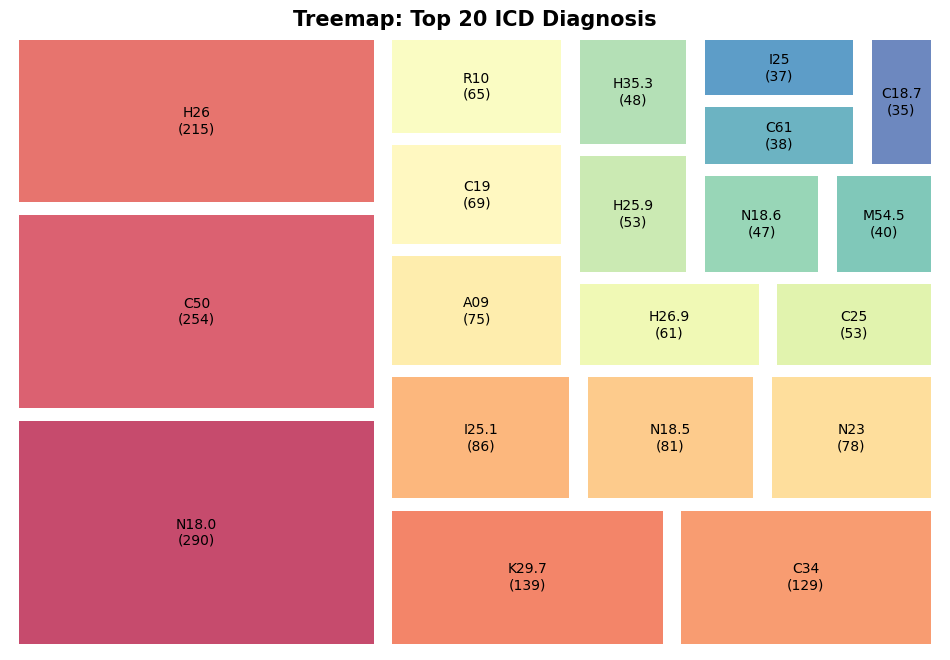

In [26]:
cat_cols_to_plot = ['ICD Diagnosis']

for col in cat_cols_to_plot:
    # Ambil Top 20 value counts
    val_counts = df_klaim[col].value_counts()
    sz = val_counts[:20]
    
    # Membuat label custom: "Nama Kategori \n (Jumlah)"
    # Ini membantu kita melihat angka pastinya langsung di visualisasi
    labels = [f"{label}\n({value})" for label, value in zip(sz.index, sz.values)]
    
    # Membuat palet warna dinamis sesuai jumlah kategori (max 20)
    colors = sns.color_palette('Spectral', len(sz))
    
    plt.figure(figsize=(12, 8))
    
    # Plotting Treemap
    squarify.plot(sizes=sz.values, label=labels, color=colors, alpha=0.8, pad=True)
    
    plt.title(f"Treemap: Top 20 {col}", fontsize=15, fontweight='bold')
    plt.axis("off")
    plt.show()

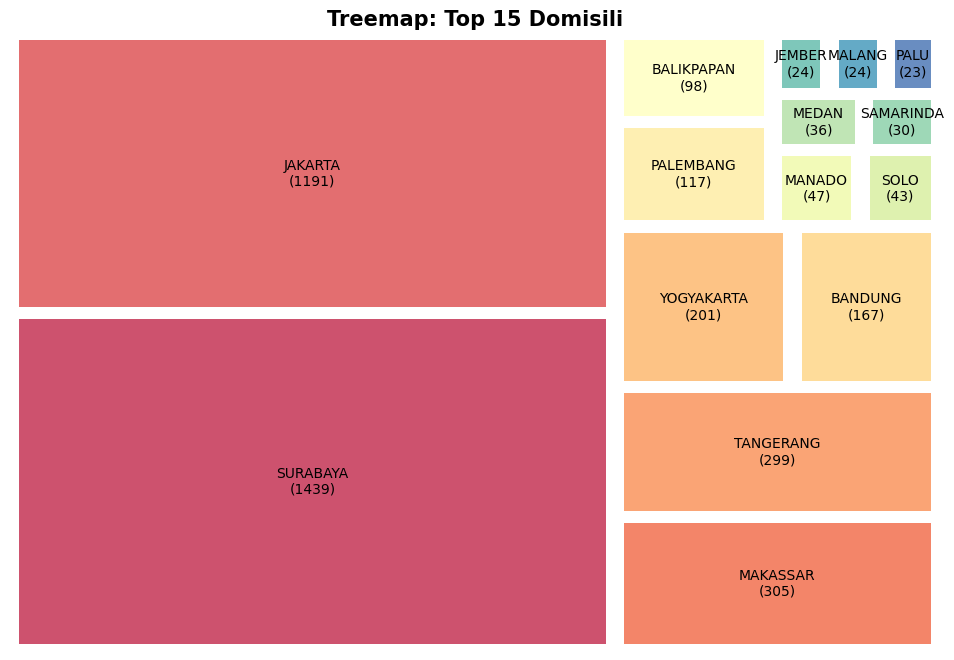

In [27]:
cat_cols_to_plot = ['Domisili']

for col in cat_cols_to_plot:
    val_counts = df_polis[col].value_counts()
    sz = val_counts[:15]
    
    # Membuat label custom: "Nama Kategori \n (Jumlah)"
    # Ini membantu kita melihat angka pastinya langsung di visualisasi
    labels = [f"{label}\n({value})" for label, value in zip(sz.index, sz.values)]
    
    # Membuat palet warna dinamis sesuai jumlah kategori (max 20)
    colors = sns.color_palette('Spectral', len(sz))
    
    plt.figure(figsize=(12, 8))
    
    # Plotting Treemap
    squarify.plot(sizes=sz.values, label=labels, color=colors, alpha=0.8, pad=True)
    
    plt.title(f"Treemap: Top 15 {col}", fontsize=15, fontweight='bold')
    plt.axis("off")
    plt.show()

In [28]:
desc_stats = df_klaim[num_col_klaim].describe().T

desc_stats['skewness'] = df_klaim[num_col_klaim].skew()
desc_stats['kurtosis'] = df_klaim[num_col_klaim].kurt()

columns_order = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis']
desc_stats = desc_stats[columns_order]

print(f"Statistik Numerik untuk {len(num_col_klaim)} fitur Data Klaim:")

display(desc_stats.style.format("{:.2f}").background_gradient(cmap='coolwarm', subset=['mean', '50%', 'skewness']))

Statistik Numerik untuk 2 fitur Data Klaim:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Nominal Klaim Yang Disetujui,4627.00,55028924.48,131952706.29,0.00,2274009.30,14467899.00,51072085.06,2197500000.00,6.64,64.60
Nominal Biaya RS Yang Terjadi,4627.00,59949398.03,159783760.50,0.00,2720209.50,15871000.00,54230667.53,3892809996.02,9.62,148.77


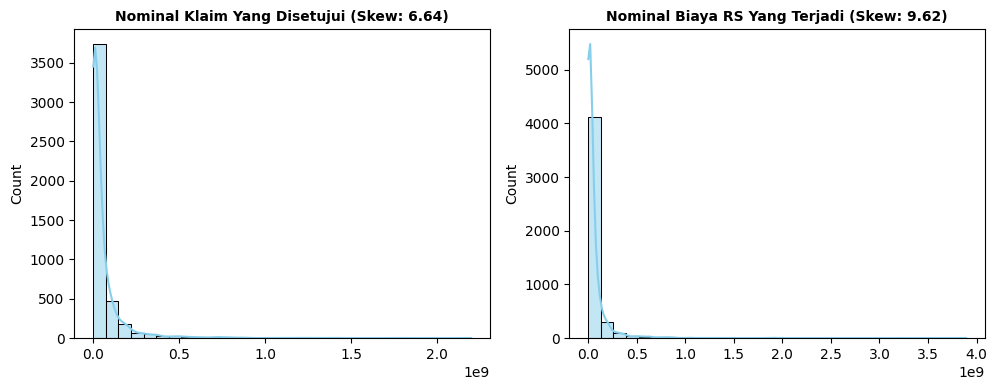

In [29]:
import math

num_col_to_plot = ['Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi']
n_cols = 3
n_rows = math.ceil(len(num_col_to_plot) / n_cols)

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(num_col_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Plot Histogram dengan KDE (Kernel Density Estimate)
    sns.histplot(df_klaim[col], kde=True, bins=30, color='skyblue')
    
    # Judul dengan nilai Skewness
    skew_val = df_klaim[col].skew()
    plt.title(f'{col} (Skew: {skew_val:.2f})', fontsize=10, fontweight='bold')
    plt.xlabel('')
    
plt.tight_layout()
plt.show()

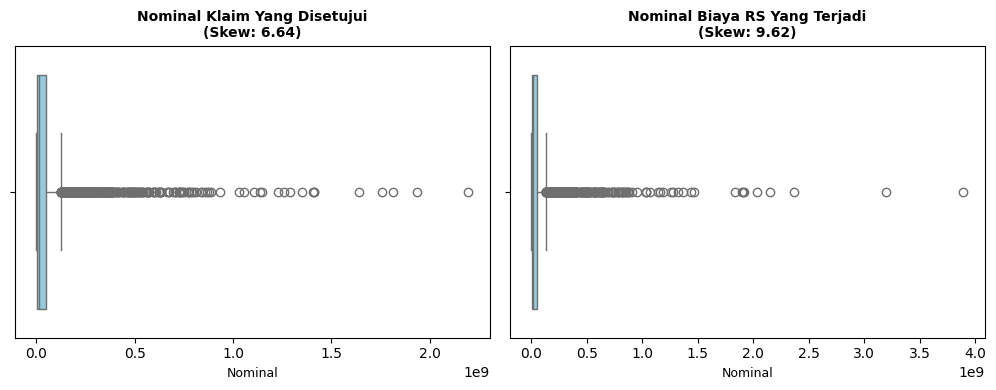

In [30]:
num_col_to_plot = ['Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi']
n_cols = 3
n_rows = math.ceil(len(num_col_to_plot) / n_cols)

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(num_col_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.boxplot(x=df_klaim[col], color='skyblue')
    
    skew_val = df_klaim[col].skew()
    plt.title(f'{col}\n(Skew: {skew_val:.2f})', fontsize=10, fontweight='bold')
    plt.xlabel('Nominal', fontsize=9)
    
plt.tight_layout()
plt.show()

In [31]:
df_klaim[df_klaim['Nominal Klaim Yang Disetujui']==0]

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
49,C-0083-M,POL-2125,R,OP,H25.9,"Senile cataract, unspecified",PAID,2024-07-26,2024-06-21,2024-06-21,0.0,75000.00,Indonesia
51,C-0085-M,POL-2125,R,OP,H25.9,"Senile cataract, unspecified",PAID,2024-07-26,2024-06-21,2024-06-21,0.0,50000.00,Indonesia
261,C-0363-M,POL-0317,R,NaN,NaN,NaN,PAID,NaT,2024-01-18,2024-01-25,0.0,4860000.00,Indonesia
623,C-0826-M,POL-3275,R,OP,S83,"Dislocation , sprain and strain of joints and ...",PAID,2024-10-03,2024-07-08,2024-07-08,0.0,2501363.16,Singapore
1380,C-1793-M,POL-3328,R,IP,K58,Irritable bowel syndrome,PAID,2024-08-05,2024-06-06,2024-06-06,0.0,173287.00,Malaysia
1412,C-1827-M,POL-3642,R,OP,K60.3,ANAL FISTULA,PAID,2024-04-30,2024-04-03,2024-04-03,0.0,88000.00,Indonesia
1935,C-2497-M,POL-2721,R,OP,S33.7,Sprain and strain of other and unspecified par...,PAID,2024-09-13,2024-07-25,2024-07-26,0.0,0.00,Singapore
2093,C-2691-M,POL-0935,R,OP,K29.7,GASTRITIS,PAID,2024-09-23,2024-07-22,2024-07-22,0.0,18123820.00,Singapore
2195,C-2840-M,POL-0856,R,IP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-29,2024-07-07,2024-07-08,0.0,3020970.00,Singapore
3767,C-4713-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-04-26,2024-01-25,2024-01-25,0.0,1854301.08,Singapore


In [32]:
df_klaim[df_klaim['Nominal Biaya RS Yang Terjadi']==0]

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
9,C-0010-M,POL-0964,R,ODC,C82.9,"Follicular non-Hodgkin's lymphoma, unspecified",PAID,NaT,2024-07-05,2024-07-05,32293868.65,0.0,Malaysia
1935,C-2497-M,POL-2721,R,OP,S33.7,Sprain and strain of other and unspecified par...,PAID,2024-09-13,2024-07-25,2024-07-26,0.00,0.0,Singapore


In [33]:
for col in ['Gender', 'Domisili', 'ICD Chapter', 'Is_Tgl_Bayar_Missing']:
    print(df_master[col].value_counts(), '\n')

Gender
F    2327
M    2300
Name: count, dtype: int64 

Domisili
SURABAYA      1831
JAKARTA       1296
TANGERANG      306
PALEMBANG      233
YOGYAKARTA     224
MAKASSAR       203
BALIKPAPAN     182
BANDUNG        115
JEMBER          44
MANADO          34
MALANG          30
MEDAN           30
SEMARANG        24
SOLO            21
PALU            19
SAMARINDA       19
BLITAR          10
KUDUS            3
BALI             2
SORONG           1
Name: count, dtype: int64 

ICD Chapter
C    935
N    719
H    549
K    543
I    383
M    372
R    229
S    176
J    173
A    159
D    144
L     79
E     57
G     46
B     27
T     23
Z      6
F      3
W      3
Q      1
Name: count, dtype: int64 

Is_Tgl_Bayar_Missing
0    4590
1      37
Name: count, dtype: int64 



## Interaksi Antar Fitur

In [34]:
df_master

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Lama Rawat Inap,Usia Saat Klaim,Durasi Polis (Bulan),ICD Chapter,Is_Tgl_Bayar_Missing
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,2.809365e+07,6.143948e+06,Singapore,M-001,F,1967-02-20,2015-01-09,JAKARTA,0,57.0,112.0,C,0
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,8.098728e+07,8.230952e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,67.0,144.0,C,0
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,1.830471e+08,1.928599e+08,Singapore,M-002,F,1959-10-21,2015-03-16,SURABAYA,0,64.0,110.0,C,0
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,1.914244e+08,1.914244e+08,Singapore,M-002,F,1959-10-21,2015-03-16,SURABAYA,0,64.0,112.0,C,0
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaT,2024-06-06,2024-06-06,1.389364e+08,1.389364e+08,Singapore,M-002,F,1968-09-06,2014-06-24,JAKARTA,0,55.0,119.0,C,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4622,C-5777-M,POL-3288,C,IP,C34,Malignant neoplasm of bronchus and lung,PAID,2025-07-02,2025-03-11,2025-03-11,1.513929e+07,1.531253e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,68.0,152.0,C,0
4623,C-5778-M,POL-3288,C,IP,C34,Malignant neoplasm of bronchus and lung,PAID,2025-07-08,2025-04-18,2025-04-18,6.336514e+07,6.620405e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,68.0,153.0,C,0
4624,C-5779-M,POL-3288,C,IP,C34.1,"Malignant neoplasm of upper lobe, bronchus or ...",PAID,NaT,2025-05-21,2025-05-21,1.632886e+07,1.651873e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,68.0,155.0,C,1
4625,C-5780-M,POL-3288,C,IP,C34.9,"Malignant neoplasm of bronchus or lung, unspec...",PAID,NaT,2025-06-30,2025-06-30,6.540838e+07,6.662646e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,68.0,156.0,C,1


=== 1. VALIDASI TREN WAKTU (H1 2024 vs H1 2025) ===
Total Nominal H1 2024 : Rp 84,209,576,821.80 | Frekuensi: 1515
Total Nominal H1 2025 : Rp 77,534,324,637.32 | Frekuensi: 1373
-> Kenaikan Nominal   : -7.93%
-> Kenaikan Frekuensi : -9.37%

=== 2. ANALISIS BIVARIAT KUNCI: Inpatient vs Outpatient ===
Inpatient/Outpatient  Count          Mean        Median              Max
                  IP   2256 Rp 83,573,003 Rp 26,718,808 Rp 2,197,500,000
                 ODC    281 Rp 59,545,793 Rp 37,213,118   Rp 570,248,866
                 ODS    110 Rp 30,849,068 Rp 16,600,431   Rp 273,304,651
                  OP   1931 Rp 23,460,569  Rp 2,688,700   Rp 539,871,796 

=== 3. VISUALISASI DISTRIBUSI SEVERITAS (LOG TRANSFORM) ===


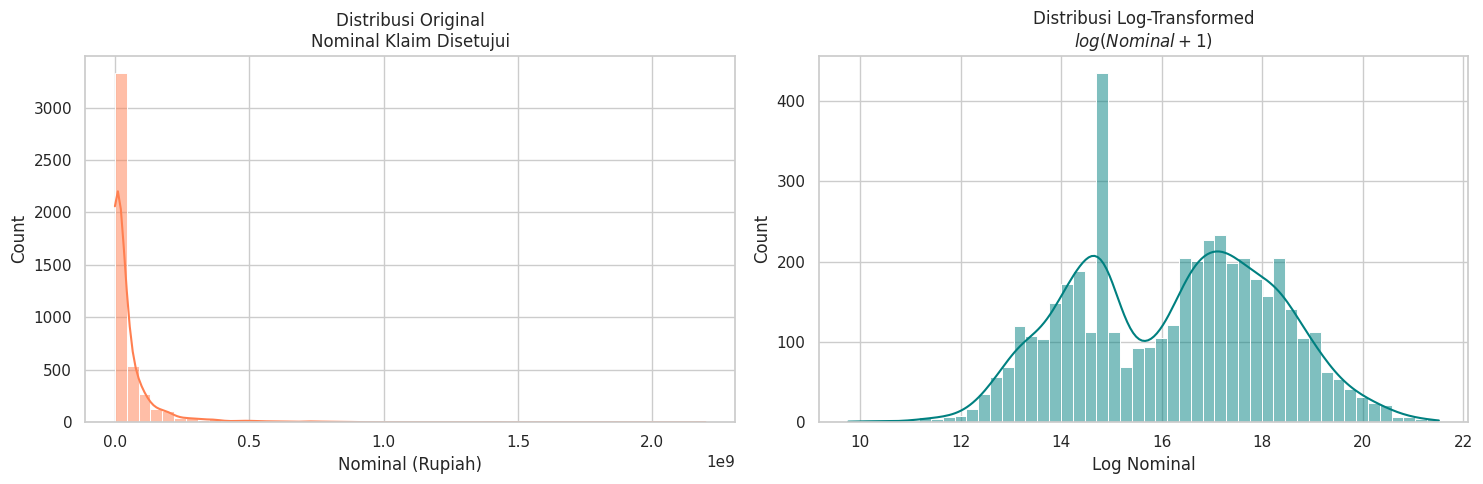

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style untuk visualisasi yang lebih elegan ala Kaggle
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.autolayout': True})

def advanced_eda_insurance(df_klaim, df_master=None):
    print("=== 1. VALIDASI TREN WAKTU (H1 2024 vs H1 2025) ===")
    # Pastikan format datetime
    df_klaim['Tanggal Pasien Masuk RS'] = pd.to_datetime(df_klaim['Tanggal Pasien Masuk RS'], errors='coerce')
    
    # Filter data untuk Jan-Jun 2024 dan Jan-Jun 2025
    h1_2024 = df_klaim[(df_klaim['Tanggal Pasien Masuk RS'] >= '2024-01-01') & 
                       (df_klaim['Tanggal Pasien Masuk RS'] <= '2024-06-30')]
    h1_2025 = df_klaim[(df_klaim['Tanggal Pasien Masuk RS'] >= '2025-01-01') & 
                       (df_klaim['Tanggal Pasien Masuk RS'] <= '2025-06-30')]
    
    klaim_h1_24 = h1_2024['Nominal Klaim Yang Disetujui'].sum()
    klaim_h1_25 = h1_2025['Nominal Klaim Yang Disetujui'].sum()
    freq_h1_24 = len(h1_24) if 'h1_24' in locals() else len(h1_2024)
    freq_h1_25 = len(h1_2025)
    
    kenaikan_nominal = ((klaim_h1_25 - klaim_h1_24) / klaim_h1_24) * 100
    kenaikan_freq = ((freq_h1_25 - freq_h1_24) / freq_h1_24) * 100
    
    print(f"Total Nominal H1 2024 : Rp {klaim_h1_24:,.2f} | Frekuensi: {freq_h1_24}")
    print(f"Total Nominal H1 2025 : Rp {klaim_h1_25:,.2f} | Frekuensi: {freq_h1_25}")
    print(f"-> Kenaikan Nominal   : {kenaikan_nominal:.2f}%")
    print(f"-> Kenaikan Frekuensi : {kenaikan_freq:.2f}%\n")


    print("=== 2. ANALISIS BIVARIAT KUNCI: Inpatient vs Outpatient ===")
    # Mengabaikan klaim bernilai 0 untuk analisis severitas
    df_valid_claim = df_klaim[df_klaim['Nominal Klaim Yang Disetujui'] > 0].copy()
    
    stats_io = df_valid_claim.groupby('Inpatient/Outpatient')['Nominal Klaim Yang Disetujui'].agg(
        Count='count',
        Mean='mean',
        Median='median',
        Max='max'
    ).reset_index()
    
    # Format agar lebih mudah dibaca
    for col in ['Mean', 'Median', 'Max']:
        stats_io[col] = stats_io[col].apply(lambda x: f"Rp {x:,.0f}")
    print(stats_io.to_string(index=False), "\n")


    print("=== 3. VISUALISASI DISTRIBUSI SEVERITAS (LOG TRANSFORM) ===")
    # Visualisasi ini penting untuk melihat apakah kita butuh transformasi Log1p
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot Original (Pasti akan sangat skewed)
    sns.histplot(df_valid_claim['Nominal Klaim Yang Disetujui'], bins=50, kde=True, ax=axes[0], color='coral')
    axes[0].set_title('Distribusi Original\nNominal Klaim Disetujui')
    axes[0].set_xlabel('Nominal (Rupiah)')
    
    # Plot Log-Transform: $log_{10}(x+1)$
    df_valid_claim['Log_Nominal'] = np.log1p(df_valid_claim['Nominal Klaim Yang Disetujui'])
    sns.histplot(df_valid_claim['Log_Nominal'], bins=50, kde=True, ax=axes[1], color='teal')
    axes[1].set_title('Distribusi Log-Transformed\n$log(Nominal + 1)$')
    axes[1].set_xlabel('Log Nominal')
    
    plt.tight_layout()
    plt.show()

# Panggil fungsinya
advanced_eda_insurance(df_klaim)

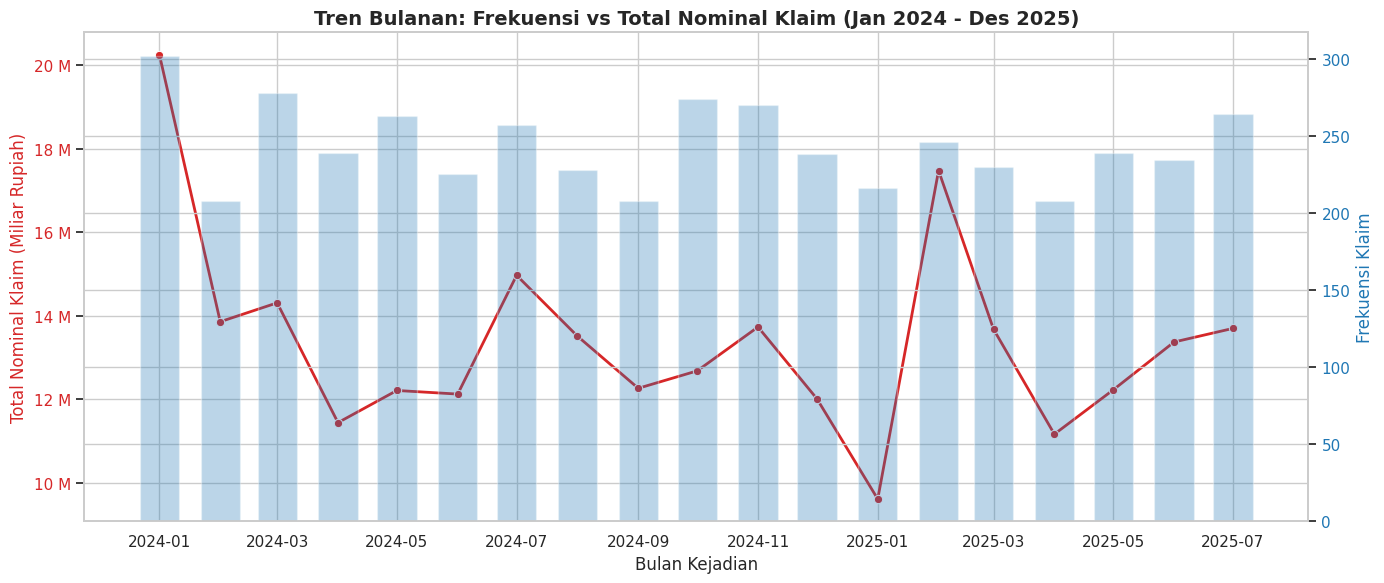

,Bulan_Tahun,Total_Nominal,Frekuensi
0,2024-01-01,2.026098e+10,302
1,2024-02-01,1.385965e+10,208
2,2024-03-01,1.431126e+10,278
3,2024-04-01,1.144106e+10,239
4,2024-05-01,1.221146e+10,263


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan setel tema visual
sns.set_theme(style="whitegrid", palette="muted")

# 1. Menyiapkan Data Agregasi Bulanan
# Menggunakan 'Tanggal Pasien Masuk RS' sebagai basis waktu kejadian (Incurred Date)
df_ts = df_master.copy()
df_ts['Bulan_Tahun'] = df_ts['Tanggal Pasien Masuk RS'].dt.to_period('M')

# Agregasi data
monthly_trend = df_ts.groupby('Bulan_Tahun').agg(
    Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum'),
    Frekuensi=('Claim ID', 'count')
).reset_index()

# Konversi kembali ke timestamp untuk plotting
monthly_trend['Bulan_Tahun'] = monthly_trend['Bulan_Tahun'].dt.to_timestamp()

# 2. Visualisasi Dual Axis (Nominal vs Frekuensi)
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:red'
ax1.set_xlabel('Bulan Kejadian', fontsize=12)
ax1.set_ylabel('Total Nominal Klaim (Miliar Rupiah)', color=color, fontsize=12)
# Plot garis untuk Nominal Klaim
sns.lineplot(data=monthly_trend, x='Bulan_Tahun', y='Total_Nominal', ax=ax1, color=color, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
# Format sumbu Y ke Miliar agar rapi
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,} M".format(int(x/1e9))))

# Axis kedua untuk Frekuensi
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Frekuensi Klaim', color=color, fontsize=12)
# Plot bar untuk Frekuensi (menggunakan bar agar kontras dengan line nominal)
ax2.bar(monthly_trend['Bulan_Tahun'], monthly_trend['Frekuensi'], color=color, alpha=0.3, width=20)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Tren Bulanan: Frekuensi vs Total Nominal Klaim (Jan 2024 - Des 2025)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Tampilkan tabel datanya juga untuk inspeksi angka eksaknya
display(monthly_trend.head())

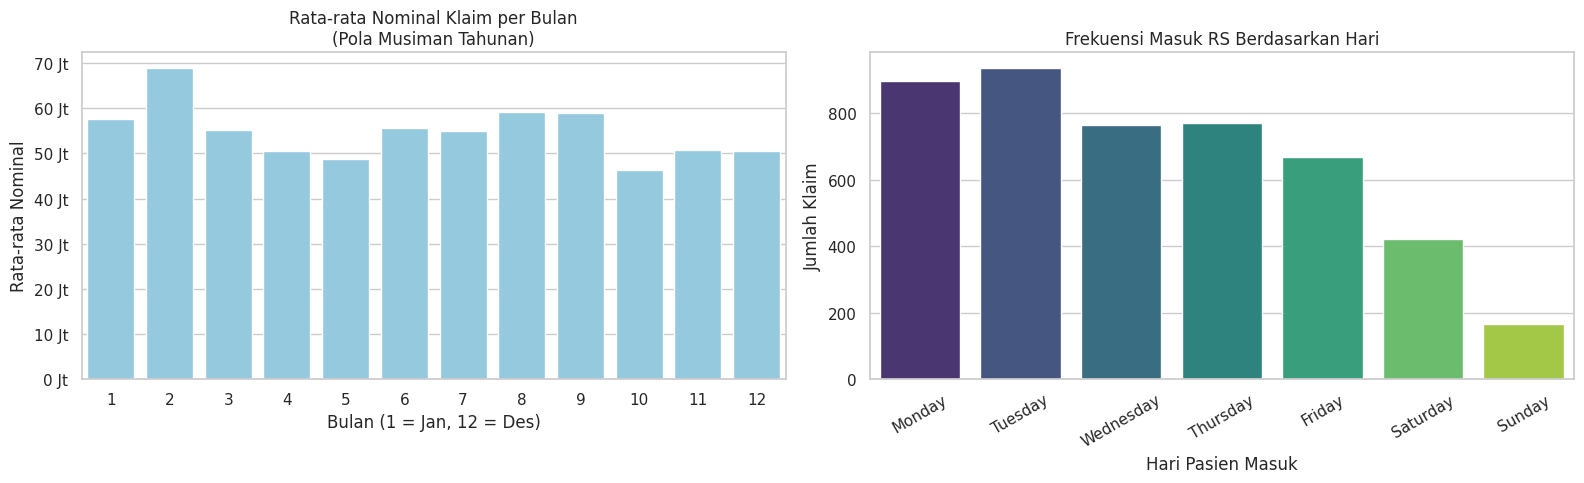

In [37]:
# 1. Ekstraksi Fitur Musiman
df_ts['Bulan_Angka'] = df_ts['Tanggal Pasien Masuk RS'].dt.month
df_ts['Hari_Masuk'] = df_ts['Tanggal Pasien Masuk RS'].dt.day_name()

# Urutan hari agar plot berurutan
hari_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Visualisasi Rata-rata Nominal berdasarkan Bulan dan Hari
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Pola Bulanan (Apakah ada 'December Effect' atau lonjakan di awal tahun?)
sns.barplot(data=df_ts, x='Bulan_Angka', y='Nominal Klaim Yang Disetujui', estimator=np.mean, errorbar=None, ax=axes[0], color='skyblue')
axes[0].set_title('Rata-rata Nominal Klaim per Bulan\n(Pola Musiman Tahunan)', fontsize=12)
axes[0].set_xlabel('Bulan (1 = Jan, 12 = Des)')
axes[0].set_ylabel('Rata-rata Nominal')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,} Jt".format(int(x/1e6))))

# Plot Pola Harian (Apakah orang lebih sering/mahal masuk RS di akhir pekan?)
sns.countplot(data=df_ts, x='Hari_Masuk', order=hari_order, ax=axes[1], palette='viridis')
axes[1].set_title('Frekuensi Masuk RS Berdasarkan Hari', fontsize=12)
axes[1].set_xlabel('Hari Pasien Masuk')
axes[1].set_ylabel('Jumlah Klaim')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

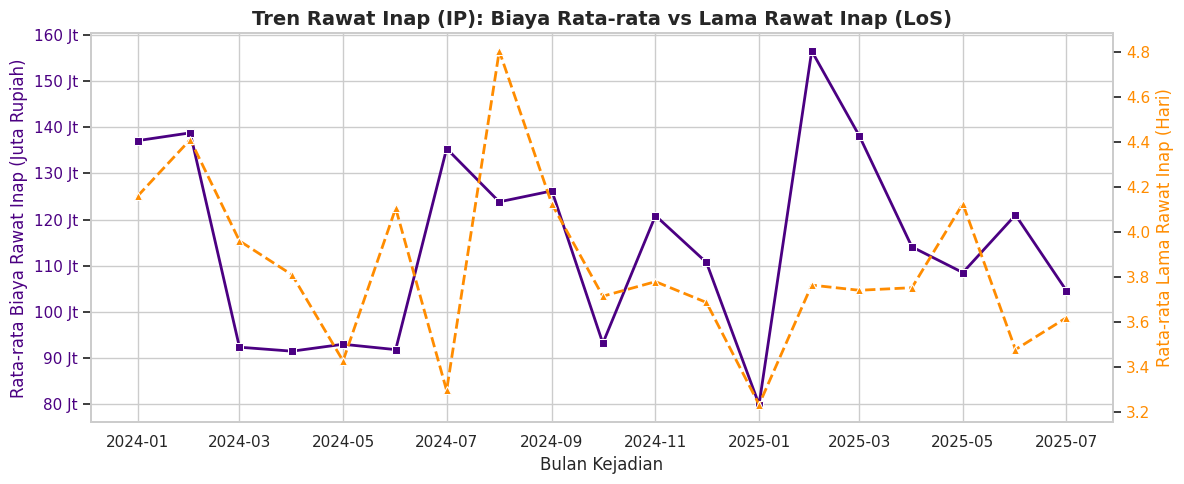

In [38]:
# 1. Filter data valid dan hilangkan Outpatient biasa untuk fokus pada rawat inap (IP)
df_ip = df_ts[(df_ts['Inpatient/Outpatient'] == 'IP') & (df_ts['Lama Rawat Inap'] > 0)].copy()

# 2. Agregasi Rata-rata Biaya dan Rata-rata Lama Inap per bulan
ip_trend = df_ip.groupby('Bulan_Tahun').agg(
    Avg_Biaya_IP=('Nominal Klaim Yang Disetujui', 'mean'),
    Avg_LoS=('Lama Rawat Inap', 'mean')
).reset_index()

# 3. FIX: Konversi Period kembali ke Timestamp agar Seaborn bisa membacanya
ip_trend['Bulan_Tahun'] = ip_trend['Bulan_Tahun'].dt.to_timestamp()

# 4. Visualisasi Dual Axis
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot Rata-rata Biaya IP
color = 'indigo'
ax1.set_xlabel('Bulan Kejadian')
ax1.set_ylabel('Rata-rata Biaya Rawat Inap (Juta Rupiah)', color=color)
sns.lineplot(data=ip_trend, x='Bulan_Tahun', y='Avg_Biaya_IP', ax=ax1, color=color, marker='s', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,} Jt".format(int(x/1e6))))

# Plot Rata-rata Lama Rawat Inap (LoS)
ax2 = ax1.twinx()
color = 'darkorange'
ax2.set_ylabel('Rata-rata Lama Rawat Inap (Hari)', color=color)
sns.lineplot(data=ip_trend, x='Bulan_Tahun', y='Avg_LoS', ax=ax2, color=color, marker='^', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Tren Rawat Inap (IP): Biaya Rata-rata vs Lama Rawat Inap (LoS)', fontsize=14, fontweight='bold')
plt.grid(False) # Mematikan grid kedua agar tidak bertumpuk
plt.tight_layout()
plt.show()

In [39]:
df_master

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Lama Rawat Inap,Usia Saat Klaim,Durasi Polis (Bulan),ICD Chapter,Is_Tgl_Bayar_Missing
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,2.809365e+07,6.143948e+06,Singapore,M-001,F,1967-02-20,2015-01-09,JAKARTA,0,57.0,112.0,C,0
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,8.098728e+07,8.230952e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,67.0,144.0,C,0
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,1.830471e+08,1.928599e+08,Singapore,M-002,F,1959-10-21,2015-03-16,SURABAYA,0,64.0,110.0,C,0
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,1.914244e+08,1.914244e+08,Singapore,M-002,F,1959-10-21,2015-03-16,SURABAYA,0,64.0,112.0,C,0
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaT,2024-06-06,2024-06-06,1.389364e+08,1.389364e+08,Singapore,M-002,F,1968-09-06,2014-06-24,JAKARTA,0,55.0,119.0,C,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4622,C-5777-M,POL-3288,C,IP,C34,Malignant neoplasm of bronchus and lung,PAID,2025-07-02,2025-03-11,2025-03-11,1.513929e+07,1.531253e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,68.0,152.0,C,0
4623,C-5778-M,POL-3288,C,IP,C34,Malignant neoplasm of bronchus and lung,PAID,2025-07-08,2025-04-18,2025-04-18,6.336514e+07,6.620405e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,68.0,153.0,C,0
4624,C-5779-M,POL-3288,C,IP,C34.1,"Malignant neoplasm of upper lobe, bronchus or ...",PAID,NaT,2025-05-21,2025-05-21,1.632886e+07,1.651873e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,68.0,155.0,C,1
4625,C-5780-M,POL-3288,C,IP,C34.9,"Malignant neoplasm of bronchus or lung, unspec...",PAID,NaT,2025-06-30,2025-06-30,6.540838e+07,6.662646e+07,Malaysia,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,0,68.0,156.0,C,1


=== EDA: ANALISIS KOHORT BERDASARKAN PLAN CODE ===


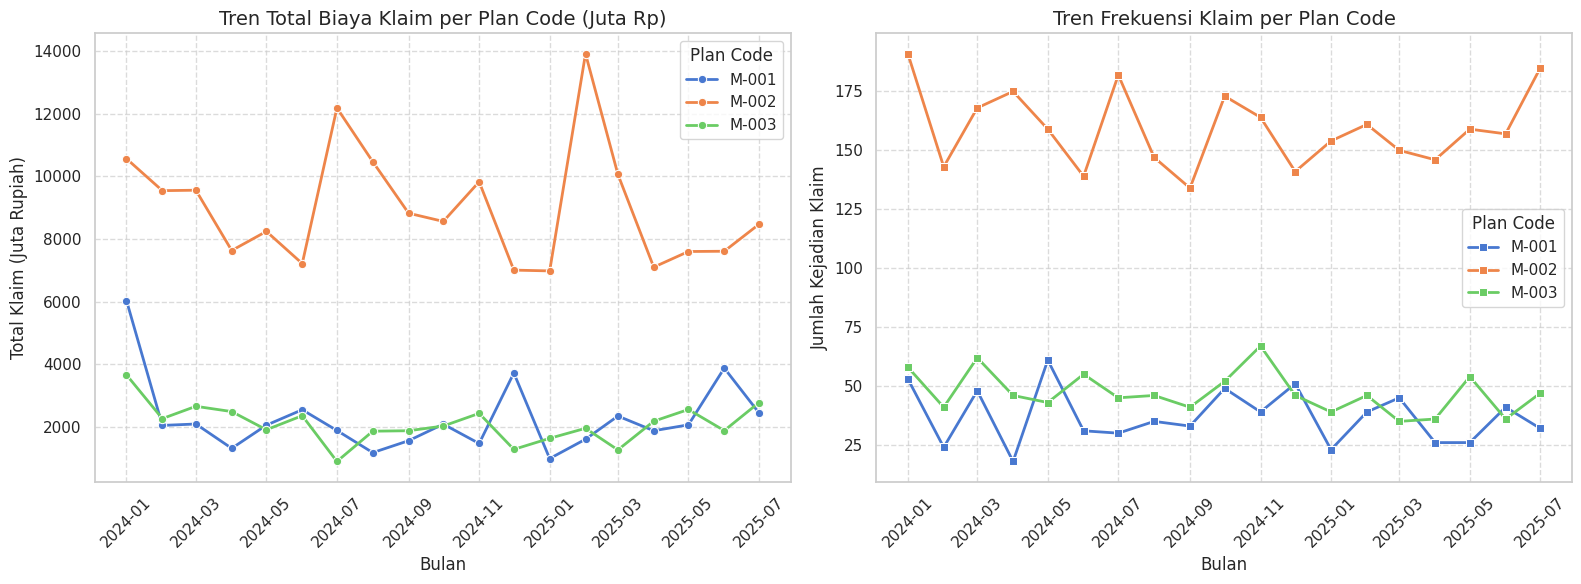


Statistik Rata-rata Bulanan per Plan Code:


,Total_Klaim_Juta,Frekuensi
Plan Code,,
M-001,2276.08,37.05
M-002,9019.16,159.37
M-003,2105.75,47.11


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("=== EDA: ANALISIS KOHORT BERDASARKAN PLAN CODE ===")

# 1. Pastikan kolom waktu sudah benar
df_master['Bulan_Tahun'] = df_master['Tanggal Pasien Masuk RS'].dt.to_period('M').dt.to_timestamp()

# PERBAIKAN: Langsung gunakan df_master karena kemungkinan sudah memiliki 'Plan Code'
df_cohort = df_master.copy()

# Cek singkat untuk memastikan kolomnya benar-benar ada
if 'Plan Code' not in df_cohort.columns:
    print("Peringatan: Kolom 'Plan Code' benar-benar tidak ada di data. Cek penulisan nama kolom (misal: 'Plan_Code' atau huruf kecil).")

# 2. Agregasi total klaim dan frekuensi per Bulan dan Plan Code
cohort_agg = df_cohort.groupby(['Bulan_Tahun', 'Plan Code']).agg(
    Total_Klaim=('Nominal Klaim Yang Disetujui', 'sum'),
    Frekuensi=('Claim ID', 'count')
).reset_index()

# Konversi ke skala Jutaan Rupiah agar mudah dibaca di grafik
cohort_agg['Total_Klaim_Juta'] = cohort_agg['Total_Klaim'] / 1_000_000

# 3. Visualisasi Tren Total Klaim Nominal
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=cohort_agg, x='Bulan_Tahun', y='Total_Klaim_Juta', hue='Plan Code', marker='o', linewidth=2)
plt.title('Tren Total Biaya Klaim per Plan Code (Juta Rp)', fontsize=14)
plt.xlabel('Bulan')
plt.ylabel('Total Klaim (Juta Rupiah)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# 4. Visualisasi Tren Frekuensi Klaim
plt.subplot(1, 2, 2)
sns.lineplot(data=cohort_agg, x='Bulan_Tahun', y='Frekuensi', hue='Plan Code', marker='s', linewidth=2)
plt.title('Tren Frekuensi Klaim per Plan Code', fontsize=14)
plt.xlabel('Bulan')
plt.ylabel('Jumlah Kejadian Klaim')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Tampilkan statistik deskriptif singkat
print("\nStatistik Rata-rata Bulanan per Plan Code:")
display(cohort_agg.groupby('Plan Code')[['Total_Klaim_Juta', 'Frekuensi']].mean().round(2))


=== EDA: PROFILING 'THE BIG SPENDERS' (TOP 5% KLAIM TERMAHAL) ===
Batas Nominal Top 5% Klaim: Rp 223,325,826.62

Jumlah Kejadian Klaim Ekstrem (> P95): 232 kejadian
Total Biaya dari Klaim Ekstrem ini: Rp 114,871,105,729.64
Persentase dari Total Biaya Portofolio: 45.11%


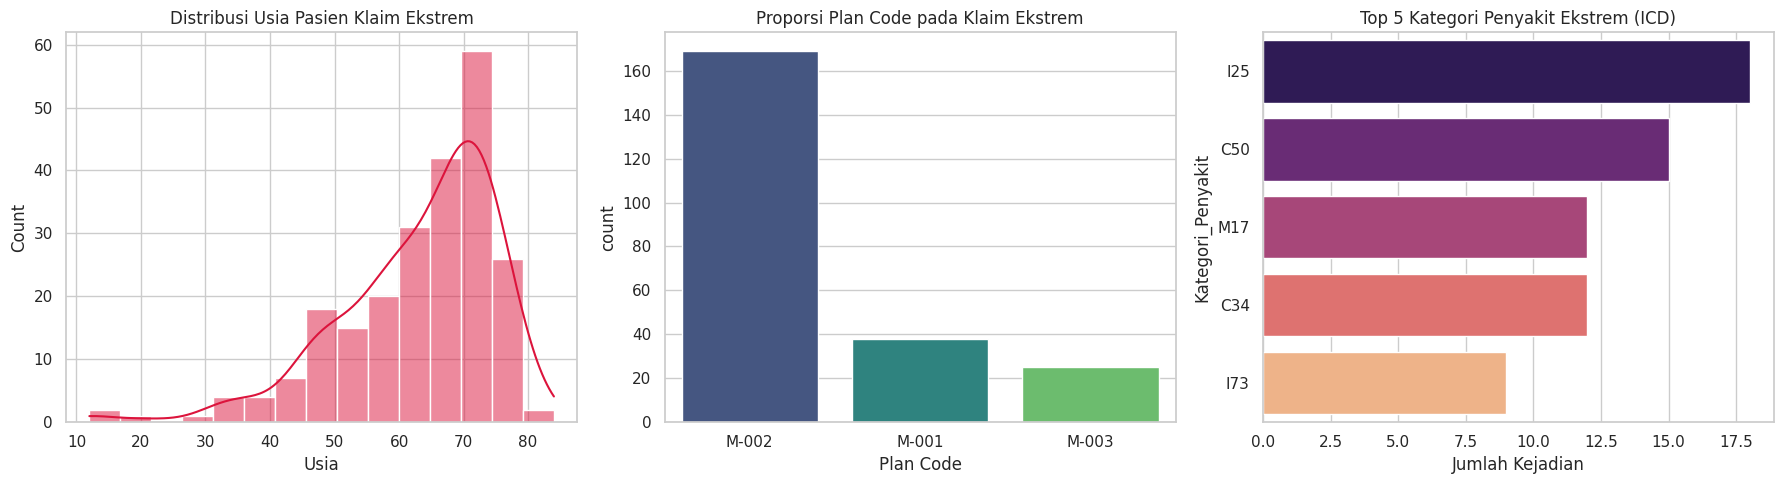


Top 5 Klaim Paling Raksasa Sepanjang Sejarah Data:


,Nomor Polis,Tanggal Pasien Masuk RS,Nominal Klaim Yang Disetujui,Inpatient/Outpatient,Kategori_Penyakit
324,POL-2551,2025-02-27,2.197500e+09,IP,I25
367,POL-2535,2025-06-20,1.938410e+09,IP,I25
252,POL-3622,2024-09-04,1.813035e+09,IP,C61
964,POL-1240,2024-02-27,1.756406e+09,IP,E87
2104,POL-0587,2025-07-04,1.643362e+09,IP,D18


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("\n=== EDA: PROFILING 'THE BIG SPENDERS' (TOP 5% KLAIM TERMAHAL) ===")

# 1. Cari batas nominal untuk masuk ke kelompok Top 5% (Persentil 95)
threshold_95 = df_master['Nominal Klaim Yang Disetujui'].quantile(0.95)
print(f"Batas Nominal Top 5% Klaim: Rp {threshold_95:,.2f}")

# 2. Filter dataset khusus untuk Big Spenders
# KITA HANYA FILTER. TIDAK ADA MERGE LAGI!
big_spenders = df_master[df_master['Nominal Klaim Yang Disetujui'] >= threshold_95].copy()

# 3. Hitung usia saat masuk RS langsung dari kolom df_master yang sudah ada
big_spenders['Usia_Saat_Sakit'] = np.floor((big_spenders['Tanggal Pasien Masuk RS'] - big_spenders['Tanggal Lahir']).dt.days / 365.25)

print(f"\nJumlah Kejadian Klaim Ekstrem (> P95): {len(big_spenders)} kejadian")
print(f"Total Biaya dari Klaim Ekstrem ini: Rp {big_spenders['Nominal Klaim Yang Disetujui'].sum():,.2f}")
print(f"Persentase dari Total Biaya Portofolio: {(big_spenders['Nominal Klaim Yang Disetujui'].sum() / df_master['Nominal Klaim Yang Disetujui'].sum()) * 100:.2f}%")

# 4. Visualisasi Profil Big Spenders
plt.figure(figsize=(18, 5))

# Plot A: Distribusi Usia
plt.subplot(1, 3, 1)
sns.histplot(big_spenders['Usia_Saat_Sakit'], bins=15, kde=True, color='crimson')
plt.title('Distribusi Usia Pasien Klaim Ekstrem')
plt.xlabel('Usia')

# Plot B: Plan Code yang paling banyak klaim ekstrem
plt.subplot(1, 3, 2)
sns.countplot(data=big_spenders, x='Plan Code', order=big_spenders['Plan Code'].value_counts().index, palette='viridis')
plt.title('Proporsi Plan Code pada Klaim Ekstrem')

# Plot C: Top 5 Diagnosis Utama penyumbang biaya ekstrem
big_spenders['Kategori_Penyakit'] = big_spenders['ICD Diagnosis'].astype(str).str[:3]
top_diseases = big_spenders['Kategori_Penyakit'].value_counts().head(5)

plt.subplot(1, 3, 3)
sns.barplot(x=top_diseases.values, y=top_diseases.index, palette='magma')
plt.title('Top 5 Kategori Penyakit Ekstrem (ICD)')
plt.xlabel('Jumlah Kejadian')

plt.tight_layout()
plt.show()

# Tampilkan beberapa baris sampel klaim paling raksasa
print("\nTop 5 Klaim Paling Raksasa Sepanjang Sejarah Data:")
display(big_spenders.nlargest(5, 'Nominal Klaim Yang Disetujui')[['Nomor Polis', 'Tanggal Pasien Masuk RS', 'Nominal Klaim Yang Disetujui', 'Inpatient/Outpatient', 'Kategori_Penyakit']])

# **3. Bottom-Up Micro-Modeling**

## Data Panel & Scalling

In [42]:
# import pandas as pd
# import numpy as np
# from itertools import product
# import warnings
# warnings.filterwarnings('ignore')

# print("=== TAHAP 1: PREPARASI DATA & TARGET SCALING ===")

# # 1. Asumsi df_master sudah ada dari proses Cleansing sebelumnya
# df_master['Bulan_Tahun'] = df_master['Tanggal Pasien Masuk RS'].dt.to_period('M').dt.to_timestamp()

# # 2. Agregasi Level Polis per Bulan
# agg_klaim = df_master.groupby(['Nomor Polis', 'Bulan_Tahun']).agg(
#     Target_Freq=('Claim ID', 'count'),
#     Target_Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum')
# ).reset_index()

# # 3. THE FIX: Target Scaling (Dibagi 1 Juta agar gradien LightGBM stabil)
# # Ini adalah kunci untuk mencegah prediksi meledak hingga triliunan
# SCALING_FACTOR = 1_000_000
# agg_klaim['Target_Total_Nominal_Scaled'] = agg_klaim['Target_Total_Nominal'] / SCALING_FACTOR

# # Hitung Rata-rata Severitas yang sudah di-scale
# agg_klaim['Target_Avg_Severity_Scaled'] = np.where(
#     agg_klaim['Target_Freq'] > 0, 
#     agg_klaim['Target_Total_Nominal_Scaled'] / agg_klaim['Target_Freq'], 
#     0
# )

# # 4. Membuat Grid Data Panel LENGKAP (Jan 2024 - Dec 2025)
# months_all = pd.date_range(start='2024-01-01', end='2025-12-31', freq='MS')
# unique_policies = df_polis['Nomor Polis'].unique()

# grid = list(product(unique_policies, months_all))
# df_panel = pd.DataFrame(grid, columns=['Nomor Polis', 'Bulan_Tahun'])

# # Gabungkan dengan target aktual historis
# df_panel = pd.merge(df_panel, agg_klaim, on=['Nomor Polis', 'Bulan_Tahun'], how='left')

# # Isi NaN dengan 0 untuk bulan historis, dan biarkan NaN untuk bulan masa depan (Aug-Dec 2025)
# target_cols = ['Target_Freq', 'Target_Total_Nominal_Scaled', 'Target_Avg_Severity_Scaled', 'Target_Total_Nominal']
# for col in target_cols:
#     df_panel.loc[df_panel['Bulan_Tahun'] < '2025-08-01', col] = df_panel.loc[df_panel['Bulan_Tahun'] < '2025-08-01', col].fillna(0)

# print(f"Bentuk Data Panel: {df_panel.shape}")
# display(df_panel[(df_panel['Bulan_Tahun'] == '2025-07-01') & (df_panel['Target_Freq'] > 0)].head(3))

In [43]:
# def build_features(df_panel_raw, df_polis_raw, anchor_month):
#     """
#     Membangun fitur berdasarkan data HINGGA anchor_month.
#     Mencegah model menggunakan prediksi sebagai fitur (mencegah snowball effect).
#     """
#     df_feat = df_panel_raw.copy()
#     anchor_dt = pd.to_datetime(anchor_month)
    
#     # 1. Gabungkan demografi
#     df_feat = pd.merge(df_feat, df_polis_raw, on='Nomor Polis', how='left')
    
#     # 2. Fitur Demografi Statis (dihitung pada saat Anchor)
#     df_feat['Usia_Saat_Anchor'] = np.floor((anchor_dt - df_feat['Tanggal Lahir']).dt.days / 365.25)
#     df_feat['Durasi_Polis_Anchor'] = np.floor((anchor_dt - df_feat['Tanggal Efektif Polis']).dt.days / 30.44)
#     df_feat['Durasi_Polis_Anchor'] = np.maximum(df_feat['Durasi_Polis_Anchor'], 0)
    
#     # 3. Fitur Historis Agregat (Rekam Jejak dari masa lalu hingga Anchor)
#     # Filter hanya data masa lalu
#     df_past = df_feat[df_feat['Bulan_Tahun'] <= anchor_dt].copy()
    
#     # Hitung statistik rekam jejak tiap polis
#     track_record = df_past.groupby('Nomor Polis').agg(
#         Total_Klaim_Historis=('Target_Freq', 'sum'),
#         Total_Nominal_Historis=('Target_Total_Nominal_Scaled', 'sum'),
#         Bulan_Aktif=('Bulan_Tahun', 'count')
#     ).reset_index()
    
#     track_record['Avg_Freq_Per_Bulan'] = track_record['Total_Klaim_Historis'] / track_record['Bulan_Aktif']
#     track_record['Avg_Nominal_Per_Bulan'] = track_record['Total_Nominal_Historis'] / track_record['Bulan_Aktif']
    
#     # Drop kolom 'Bulan_Aktif' agar tidak duplicate
#     track_record = track_record.drop(columns=['Bulan_Aktif'])
    
#     # Gabungkan kembali ke dataframe utama
#     df_feat = pd.merge(df_feat, track_record, on='Nomor Polis', how='left')
    
#     # 4. Fitur Lag Spesifik dari Anchor (misal: apa yang terjadi di bulan Anchor dan Anchor-1)
#     past_sorted = df_past.sort_values(['Nomor Polis', 'Bulan_Tahun'])
#     last_1 = past_sorted[past_sorted['Bulan_Tahun'] == anchor_dt][['Nomor Polis', 'Target_Freq', 'Target_Total_Nominal_Scaled']]
#     last_1.columns = ['Nomor Polis', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir']
    
#     df_feat = pd.merge(df_feat, last_1, on='Nomor Polis', how='left')
    
#     # 5. Fitur Penanda Waktu Prediksi (Time Horizon)
#     # Seberapa jauh bulan yang diprediksi dari Anchor?
#     df_feat['Bulan_Angka'] = df_feat['Bulan_Tahun'].dt.month
#     df_feat['Horizon_Bulan'] = np.floor((df_feat['Bulan_Tahun'] - anchor_dt).dt.days / 30.44)
    
#     # 6. Bersihkan kolom dan ubah tipe kategori
#     cat_cols = ['Plan Code', 'Gender', 'Domisili']
#     for col in cat_cols:
#         df_feat[col] = df_feat[col].astype('category')
        
#     cols_to_drop = ['Tanggal Lahir', 'Tanggal Efektif Polis']
#     df_feat = df_feat.drop(columns=cols_to_drop)
    
#     return df_feat

# print("Fungsi Feature Engineering berbasis Anchor berhasil dibuat!")

## Cross Validation

In [44]:
# import pandas as pd
# import numpy as np

# print("=== MEMBANGUN DATA TRAINING (SLIDING WINDOW STACKING) ===")

# training_frames = []
# # Kita gunakan berbagai bulan di masa lalu sebagai Anchor untuk melatih model
# # Anchor dari Juni 2024 hingga Jan 2025
# historical_anchors = pd.date_range(start='2024-06-01', end='2025-01-01', freq='MS')

# for hist_anchor in historical_anchors:
#     # Ekstrak fitur seolah-olah kita sedang berada di bulan hist_anchor
#     df_hist = build_features(df_panel, df_polis, hist_anchor)
    
#     # Ambil target aktual HANYA untuk 1 sampai 5 bulan ke depan (Horizon 1-5)
#     mask_target = (df_hist['Bulan_Tahun'] > hist_anchor) & \
#                   (df_hist['Bulan_Tahun'] <= hist_anchor + pd.DateOffset(months=5))
    
#     df_target = df_hist[mask_target].copy()
#     training_frames.append(df_target)

# # Tumpuk semua simulasi menjadi satu dataset training
# df_train_stacked = pd.concat(training_frames, ignore_index=True)

# # Definisikan fitur prediktor
# features = [
#     'Usia_Saat_Anchor', 'Durasi_Polis_Anchor', 'Avg_Freq_Per_Bulan', 
#     'Avg_Nominal_Per_Bulan', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir',
#     'Bulan_Angka', 'Horizon_Bulan', 'Plan Code', 'Gender', 'Domisili'
# ]

# print(f"Total baris data training stacked: {df_train_stacked.shape[0]}")
# print("Fitur siap digunakan:", features)

In [45]:
# import lightgbm as lgb
# import warnings
# warnings.filterwarnings('ignore')

# def calculate_mape(y_true, y_pred):
#     y_true, y_pred = np.array(y_true), np.array(y_pred)
#     mask = y_true != 0
#     if not mask.any(): return 0.0
#     return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

# print("\n=== SIMULASI CROSS-VALIDATION (ANCHOR: FEB 2025) ===")

# # 1. SETUP DATA TEST (SIMULASI KAGGLE)
# anchor_cv = pd.to_datetime('2025-02-01')
# df_cv_test = build_features(df_panel, df_polis, anchor_cv)

# # Ambil 5 bulan ke depan untuk dites (Maret - Juli 2025)
# mask_cv_test = (df_cv_test['Bulan_Tahun'] > anchor_cv) & \
#                (df_cv_test['Bulan_Tahun'] <= anchor_cv + pd.DateOffset(months=5))
# df_test_sim = df_cv_test[mask_cv_test].copy()

# # 2. TRAINING MODEL (ZIP & TWEEDIE)
# # Pastikan data training tidak membocorkan data dari bulan Maret 2025 ke atas!
# X_train = df_train_stacked[df_train_stacked['Bulan_Tahun'] <= anchor_cv].copy()
# X_train['Is_Claim'] = (X_train['Target_Freq'] > 0).astype(int)

# # a. Model Klasifikasi (ZIP - Probabilitas)
# clf_model = lgb.LGBMClassifier(objective='binary', class_weight='balanced', n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1)
# clf_model.fit(X_train[features], X_train['Is_Claim'])

# # Filter hanya yang klaim untuk regresi
# train_claim_only = X_train[X_train['Is_Claim'] == 1]

# # b. Model Poisson (ZIP - Frekuensi)
# poi_model = lgb.LGBMRegressor(objective='poisson', n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1)
# poi_model.fit(train_claim_only[features], train_claim_only['Target_Freq'])

# # c. Model Severitas (Tweedie) -> Target sudah di-scale!
# tw_model = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1)
# tw_model.fit(train_claim_only[features], train_claim_only['Target_Avg_Severity_Scaled'])

# # 3. PREDIKSI DATA TEST
# # Karena kita pakai Direct Forecasting, kita bisa memprediksi ke-5 bulan SEKALIGUS tanpa looping!
# prob_claim = clf_model.predict_proba(df_test_sim[features])[:, 1]
# pred_freq = poi_model.predict(df_test_sim[features])
# df_test_sim['Pred_Freq'] = prob_claim * pred_freq

# pred_sev_scaled = tw_model.predict(df_test_sim[features])
# # KEMBALIKAN KE SKALA ASLI (Dikalikan 1 Juta)
# df_test_sim['Pred_Total_Nominal'] = df_test_sim['Pred_Freq'] * (pred_sev_scaled * SCALING_FACTOR)

# # 4. AGREGASI & EVALUASI MAPE LEVEL PORTOFOLIO
# agg_val = df_test_sim.groupby('Bulan_Tahun').agg(
#     Aktual_Freq=('Target_Freq', 'sum'),
#     Aktual_Total=('Target_Total_Nominal', 'sum'), # Kolom asli yang belum di-scale
#     Pred_Freq=('Pred_Freq', 'sum'),
#     Pred_Total=('Pred_Total_Nominal', 'sum')
# ).reset_index()

# agg_val['Aktual_Sev'] = np.where(agg_val['Aktual_Freq'] > 0, agg_val['Aktual_Total'] / agg_val['Aktual_Freq'], 0)
# agg_val['Pred_Sev'] = np.where(agg_val['Pred_Freq'] > 0, agg_val['Pred_Total'] / agg_val['Pred_Freq'], 0)

# # Terapkan trik Under-forecasting (kalikan hasil akhir total nominal dengan 0.95 agar aman dari pinalti MAPE)
# agg_val['Pred_Total'] = agg_val['Pred_Total'] * 0.95

# print("\n--- HASIL VALIDASI LEVEL PORTOFOLIO ---")
# display(agg_val[['Bulan_Tahun', 'Aktual_Freq', 'Pred_Freq', 'Aktual_Total', 'Pred_Total']])

# mape_freq = calculate_mape(agg_val['Aktual_Freq'], agg_val['Pred_Freq'])
# mape_sev = calculate_mape(agg_val['Aktual_Sev'], agg_val['Pred_Sev'])
# mape_total = calculate_mape(agg_val['Aktual_Total'], agg_val['Pred_Total'])
# mape_akhir = (mape_freq + mape_sev + mape_total) / 3

# print(f"\nSkor Akhir CV (MAPE) -> Freq: {mape_freq:.4f} | Sev: {mape_sev:.4f} | Total: {mape_total:.4f}")
# print(f"SKOR MAPE KESELURUHAN: {mape_akhir:.4f}")

In [46]:
# import lightgbm as lgb
# import warnings
# warnings.filterwarnings('ignore')

# def calculate_mape(y_true, y_pred):
#     y_true, y_pred = np.array(y_true), np.array(y_pred)
#     mask = y_true != 0
#     if not mask.any(): return 0.0
#     return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

# print("\n=== SIMULASI CROSS-VALIDATION (ANCHOR: FEB 2025) ===")

# # 1. SETUP DATA TEST (SIMULASI KAGGLE)
# anchor_cv = pd.to_datetime('2025-02-01')
# df_cv_test = build_features(df_panel, df_polis, anchor_cv)

# # Ambil 5 bulan ke depan untuk dites (Maret - Juli 2025)
# mask_cv_test = (df_cv_test['Bulan_Tahun'] > anchor_cv) & \
#                (df_cv_test['Bulan_Tahun'] <= anchor_cv + pd.DateOffset(months=5))
# df_test_sim = df_cv_test[mask_cv_test].copy()

# # 2. TRAINING MODEL (ZIP & TWEEDIE)
# X_train = df_train_stacked[df_train_stacked['Bulan_Tahun'] <= anchor_cv].copy()
# X_train['Is_Claim'] = (X_train['Target_Freq'] > 0).astype(int)

# # a. THE FIX: Hapus class_weight='balanced' agar probabilitas terkalibrasi secara natural!
# clf_model = lgb.LGBMClassifier(
#     objective='binary', 
#     n_estimators=100, 
#     learning_rate=0.05, 
#     random_state=42, 
#     n_jobs=-1, 
#     verbose=-1
# )
# clf_model.fit(X_train[features], X_train['Is_Claim'])

# # Filter hanya yang klaim untuk regresi
# train_claim_only = X_train[X_train['Is_Claim'] == 1]

# # b. Model Poisson (ZIP - Frekuensi)
# poi_model = lgb.LGBMRegressor(
#     objective='poisson', 
#     n_estimators=100, 
#     learning_rate=0.05, 
#     random_state=42, 
#     n_jobs=-1, 
#     verbose=-1
# )
# poi_model.fit(train_claim_only[features], train_claim_only['Target_Freq'])

# # c. Model Severitas (Tweedie)
# tw_model = lgb.LGBMRegressor(
#     objective='tweedie', 
#     tweedie_variance_power=1.5, 
#     n_estimators=100, 
#     learning_rate=0.05, 
#     random_state=42, 
#     n_jobs=-1, 
#     verbose=-1
# )
# tw_model.fit(train_claim_only[features], train_claim_only['Target_Avg_Severity_Scaled'])

# # 3. PREDIKSI DATA TEST
# prob_claim = clf_model.predict_proba(df_test_sim[features])[:, 1]
# pred_freq = poi_model.predict(df_test_sim[features])
# df_test_sim['Pred_Freq'] = prob_claim * pred_freq

# pred_sev_scaled = tw_model.predict(df_test_sim[features])
# # KEMBALIKAN KE SKALA ASLI
# df_test_sim['Pred_Total_Nominal'] = df_test_sim['Pred_Freq'] * (pred_sev_scaled * SCALING_FACTOR)

# # 4. AGREGASI & EVALUASI MAPE LEVEL PORTOFOLIO
# agg_val = df_test_sim.groupby('Bulan_Tahun').agg(
#     Aktual_Freq=('Target_Freq', 'sum'),
#     Aktual_Total=('Target_Total_Nominal', 'sum'),
#     Pred_Freq=('Pred_Freq', 'sum'),
#     Pred_Total=('Pred_Total_Nominal', 'sum')
# ).reset_index()

# agg_val['Aktual_Sev'] = np.where(agg_val['Aktual_Freq'] > 0, agg_val['Aktual_Total'] / agg_val['Aktual_Freq'], 0)
# agg_val['Pred_Sev'] = np.where(agg_val['Pred_Freq'] > 0, agg_val['Pred_Total'] / agg_val['Pred_Freq'], 0)

# # Trik Under-forecasting (kalikan 0.95 agar lebih aman dari penalti over-predict MAPE)
# agg_val['Pred_Total'] = agg_val['Pred_Total'] * 0.95

# print("\n--- HASIL VALIDASI LEVEL PORTOFOLIO ---")
# display(agg_val[['Bulan_Tahun', 'Aktual_Freq', 'Pred_Freq', 'Aktual_Total', 'Pred_Total']])

# mape_freq = calculate_mape(agg_val['Aktual_Freq'], agg_val['Pred_Freq'])
# mape_sev = calculate_mape(agg_val['Aktual_Sev'], agg_val['Pred_Sev'])
# mape_total = calculate_mape(agg_val['Aktual_Total'], agg_val['Pred_Total'])
# mape_akhir = (mape_freq + mape_sev + mape_total) / 3

# print(f"\nSkor Akhir CV (MAPE) -> Freq: {mape_freq:.4f} | Sev: {mape_sev:.4f} | Total: {mape_total:.4f}")
# print(f"SKOR MAPE KESELURUHAN: {mape_akhir:.4f}")

## Training

In [47]:
# import pandas as pd
# import numpy as np
# import lightgbm as lgb
# import warnings
# warnings.filterwarnings('ignore')

# print("=== TAHAP AKHIR: FULL TRAINING & GENERATE SUBMISSION ===")

# # 1. SETUP ANCHOR FINAL (JULI 2025)
# anchor_final = pd.to_datetime('2025-07-01')
# df_final_test = build_features(df_panel, df_polis, anchor_final)

# # Ambil 5 bulan ke depan untuk diprediksi (Agustus - Desember 2025)
# mask_final_test = (df_final_test['Bulan_Tahun'] > anchor_final) & \
#                   (df_final_test['Bulan_Tahun'] <= anchor_final + pd.DateOffset(months=5))
# df_test_submit = df_final_test[mask_final_test].copy()

# # 2. TRAINING MODEL DENGAN SELURUH DATA MAKSIMAL
# # Menggunakan seluruh data stacked hingga Juli 2025 agar model secerdas mungkin
# X_train_full = df_train_stacked[df_train_stacked['Bulan_Tahun'] <= anchor_final].copy()
# X_train_full['Is_Claim'] = (X_train_full['Target_Freq'] > 0).astype(int)

# print("Melatih Model ZIP (Klasifikasi & Poisson)...")
# clf_final = lgb.LGBMClassifier(objective='binary', n_estimators=120, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1)
# clf_final.fit(X_train_full[features], X_train_full['Is_Claim'])

# train_claim_full = X_train_full[X_train_full['Is_Claim'] == 1]

# poi_final = lgb.LGBMRegressor(objective='poisson', n_estimators=120, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1)
# poi_final.fit(train_claim_full[features], train_claim_full['Target_Freq'])

# print("Melatih Model Severitas (Tweedie)...")
# tw_final = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, n_estimators=120, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1)
# tw_final.fit(train_claim_full[features], train_claim_full['Target_Avg_Severity_Scaled'])

# # 3. LAKUKAN PREDIKSI UNTUK KAGGLE (Agustus - Des 2025)
# print("Menjalankan Prediksi Direct Forecasting...")
# prob_claim_sub = clf_final.predict_proba(df_test_submit[features])[:, 1]
# pred_freq_sub = poi_final.predict(df_test_submit[features])
# df_test_submit['Pred_Freq'] = prob_claim_sub * pred_freq_sub

# pred_sev_scaled_sub = tw_final.predict(df_test_submit[features])
# # Kembalikan ke Rupiah (dikalikan 1 Juta)
# df_test_submit['Pred_Total_Nominal'] = df_test_submit['Pred_Freq'] * (pred_sev_scaled_sub * SCALING_FACTOR)

# # 4. AGREGASI LEVEL PORTOFOLIO BULANAN
# agg_submit = df_test_submit.groupby('Bulan_Tahun').agg(
#     Total_Freq=('Pred_Freq', 'sum'),
#     Total_Nominal=('Pred_Total_Nominal', 'sum')
# ).reset_index()

# # Hitung Rata-rata Severitas Level Portofolio
# agg_submit['Total_Sev'] = np.where(agg_submit['Total_Freq'] > 0, agg_submit['Total_Nominal'] / agg_submit['Total_Freq'], 0)

# # Terapkan trik Under-forecasting 0.95 agar aman dari pinalti MAPE yang asimetris
# agg_submit['Total_Nominal'] = agg_submit['Total_Nominal'] * 0.95

# # 5. FORMATTING FILE KAGGLE (Melt to ID & Value)
# submission_rows = []

# for index, row in agg_submit.iterrows():
#     # Format YYYY-MM
#     year_month = row['Bulan_Tahun'].strftime('%Y_%m')
    
#     submission_rows.append({'id': f"{year_month}_Claim_Frequency", 'value': row['Total_Freq']})
#     submission_rows.append({'id': f"{year_month}_Claim_Severity", 'value': row['Total_Sev']})
#     submission_rows.append({'id': f"{year_month}_Total_Claim", 'value': row['Total_Nominal']})

In [48]:
# df_final_submission = pd.DataFrame(submission_rows)
# csv_filename = 'submission_zip_direct.csv'
# df_final_submission.to_csv(csv_filename, index=False)

In [49]:
# df_final_submission

# **4. Ekstraksi Fitur Klinis + Optuna**

## Ekstraksi Fitur Klinis & Re-arsitektur Data Panel

In [50]:
# import pandas as pd
# import numpy as np
# from itertools import product
# import warnings
# warnings.filterwarnings('ignore')

# print("=== TAHAP 1A: EKSTRAKSI FITUR KLINIS & SCALING ===")

# # 1. Asumsi df_master sudah ada (hasil merge df_klaim dan df_polis)
# df_master['Bulan_Tahun'] = df_master['Tanggal Pasien Masuk RS'].dt.to_period('M').dt.to_timestamp()

# # 2. Ekstraksi Fitur Klinis Level Kejadian (One-Hot Encoding Manual yang Efisien)
# # Identifikasi Rawat Inap (Sangat berpengaruh ke biaya)
# df_master['Is_IP'] = (df_master['Inpatient/Outpatient'] == 'IP').astype(int)

# # Identifikasi Penyakit Berat (ICD Chapter C = Kanker/Neoplasma, I = Kardiovaskular)
# # Kita ambil huruf pertama dari ICD Diagnosis
# df_master['ICD_Chapter'] = df_master['ICD Diagnosis'].astype(str).str[0].str.upper()
# df_master['Is_ICD_C'] = (df_master['ICD_Chapter'] == 'C').astype(int) # Kanker
# df_master['Is_ICD_I'] = (df_master['ICD_Chapter'] == 'I').astype(int) # Jantung/Peredaran Darah

# # 3. Agregasi Level Polis per Bulan (Target & Klinis)
# agg_klaim = df_master.groupby(['Nomor Polis', 'Bulan_Tahun']).agg(
#     Target_Freq=('Claim ID', 'count'),
#     Target_Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum'),
#     Bulan_Ini_IP=('Is_IP', 'sum'),
#     Bulan_Ini_ICD_C=('Is_ICD_C', 'sum'),
#     Bulan_Ini_ICD_I=('Is_ICD_I', 'sum')
# ).reset_index()

# # 4. Target Scaling (Mencegah Gradient Explosion)
# SCALING_FACTOR = 1_000_000
# agg_klaim['Target_Total_Nominal_Scaled'] = agg_klaim['Target_Total_Nominal'] / SCALING_FACTOR
# agg_klaim['Target_Avg_Severity_Scaled'] = np.where(
#     agg_klaim['Target_Freq'] > 0, 
#     agg_klaim['Target_Total_Nominal_Scaled'] / agg_klaim['Target_Freq'], 
#     0
# )

# # 5. Membuat Grid Data Panel LENGKAP (Jan 2024 - Dec 2025)
# months_all = pd.date_range(start='2024-01-01', end='2025-12-31', freq='MS')
# unique_policies = df_polis['Nomor Polis'].unique()

# grid = list(product(unique_policies, months_all))
# df_panel_base = pd.DataFrame(grid, columns=['Nomor Polis', 'Bulan_Tahun'])

# # Gabungkan dengan target dan fitur klinis historis
# df_panel_base = pd.merge(df_panel_base, agg_klaim, on=['Nomor Polis', 'Bulan_Tahun'], how='left')

# # Isi NaN dengan 0 untuk bulan historis
# cols_to_fill = [
#     'Target_Freq', 'Target_Total_Nominal_Scaled', 'Target_Avg_Severity_Scaled', 
#     'Target_Total_Nominal', 'Bulan_Ini_IP', 'Bulan_Ini_ICD_C', 'Bulan_Ini_ICD_I'
# ]
# for col in cols_to_fill:
#     df_panel_base.loc[df_panel_base['Bulan_Tahun'] < '2025-08-01', col] = \
#         df_panel_base.loc[df_panel_base['Bulan_Tahun'] < '2025-08-01', col].fillna(0)

# print(f"Bentuk Base Data Panel: {df_panel_base.shape}")
# display(df_panel_base[(df_panel_base['Target_Freq'] > 0)].head(3))

In [51]:
# def build_features_upgraded(df_panel_raw, df_polis_raw, anchor_month):
#     """
#     Membangun fitur demografi dan KLINIS historis berdasarkan data HINGGA anchor_month.
#     """
#     df_feat = df_panel_raw.copy()
#     anchor_dt = pd.to_datetime(anchor_month)
    
#     # 1. Gabungkan demografi statis
#     df_feat = pd.merge(df_feat, df_polis_raw, on='Nomor Polis', how='left')
    
#     df_feat['Usia_Saat_Anchor'] = np.floor((anchor_dt - df_feat['Tanggal Lahir']).dt.days / 365.25)
#     df_feat['Durasi_Polis_Anchor'] = np.floor((anchor_dt - df_feat['Tanggal Efektif Polis']).dt.days / 30.44)
#     df_feat['Durasi_Polis_Anchor'] = np.maximum(df_feat['Durasi_Polis_Anchor'], 0)
    
#     # 2. Rekam Jejak Kinerja & Klinis (Filter masa lalu hingga Anchor)
#     df_past = df_feat[df_feat['Bulan_Tahun'] <= anchor_dt].copy()
    
#     track_record = df_past.groupby('Nomor Polis').agg(
#         Total_Klaim_Historis=('Target_Freq', 'sum'),
#         Total_Nominal_Historis=('Target_Total_Nominal_Scaled', 'sum'),
#         Riwayat_Rawat_Inap=('Bulan_Ini_IP', 'sum'),
#         Riwayat_Kanker=('Bulan_Ini_ICD_C', 'sum'),
#         Riwayat_Jantung=('Bulan_Ini_ICD_I', 'sum'),
#         Bulan_Aktif=('Bulan_Tahun', 'count')
#     ).reset_index()
    
#     track_record['Avg_Freq_Per_Bulan'] = track_record['Total_Klaim_Historis'] / track_record['Bulan_Aktif']
#     track_record['Avg_Nominal_Per_Bulan'] = track_record['Total_Nominal_Historis'] / track_record['Bulan_Aktif']
    
#     # Flag biner tambahan yang sangat disukai tree-based model
#     track_record['Pernah_Kanker'] = (track_record['Riwayat_Kanker'] > 0).astype(int)
#     track_record['Pernah_Rawat_Inap'] = (track_record['Riwayat_Rawat_Inap'] > 0).astype(int)
    
#     track_record = track_record.drop(columns=['Bulan_Aktif'])
    
#     # Gabungkan fitur historis ini ke panel utama
#     df_feat = pd.merge(df_feat, track_record, on='Nomor Polis', how='left')
    
#     # 3. Fitur Lag Spesifik (Kondisi 1 bulan terakhir sebelum prediksi)
#     past_sorted = df_past.sort_values(['Nomor Polis', 'Bulan_Tahun'])
#     last_1 = past_sorted[past_sorted['Bulan_Tahun'] == anchor_dt][['Nomor Polis', 'Target_Freq', 'Target_Total_Nominal_Scaled', 'Bulan_Ini_IP']]
#     last_1.columns = ['Nomor Polis', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir', 'IP_Bulan_Terakhir']
    
#     df_feat = pd.merge(df_feat, last_1, on='Nomor Polis', how='left')
    
#     # 4. Horizon & Seasonality
#     df_feat['Bulan_Angka'] = df_feat['Bulan_Tahun'].dt.month
#     df_feat['Horizon_Bulan'] = np.floor((df_feat['Bulan_Tahun'] - anchor_dt).dt.days / 30.44)
    
#     # 5. Clean Up & Kategorisasi
#     cat_cols = ['Plan Code', 'Gender', 'Domisili']
#     for col in cat_cols:
#         df_feat[col] = df_feat[col].astype('category')
        
#     cols_to_drop = ['Tanggal Lahir', 'Tanggal Efektif Polis', 'Bulan_Ini_IP', 'Bulan_Ini_ICD_C', 'Bulan_Ini_ICD_I']
#     df_feat = df_feat.drop(columns=cols_to_drop, errors='ignore')
    
#     return df_feat

# print("Fungsi Upgraded Feature Engineering (Klinis) berhasil dibuat!")

## Re-stacking Data & Hyperparam Tuning

In [52]:
# import pandas as pd
# import numpy as np

# print("=== TAHAP 2A: MEMBANGUN DATA TRAINING (DENGAN FITUR KLINIS) ===")

# training_frames = []
# # Anchor dari Juni 2024 hingga Jan 2025
# historical_anchors = pd.date_range(start='2024-06-01', end='2025-01-01', freq='MS')

# for hist_anchor in historical_anchors:
#     # Menggunakan fungsi UPGRADED
#     df_hist = build_features_upgraded(df_panel_base, df_polis, hist_anchor)
    
#     # Ambil target aktual 1 sampai 5 bulan ke depan
#     mask_target = (df_hist['Bulan_Tahun'] > hist_anchor) & \
#                   (df_hist['Bulan_Tahun'] <= hist_anchor + pd.DateOffset(months=5))
    
#     df_target = df_hist[mask_target].copy()
#     training_frames.append(df_target)

# # Tumpuk semua simulasi menjadi satu dataset training
# df_train_stacked = pd.concat(training_frames, ignore_index=True)

# # DAFTAR FITUR BARU (Termasuk Klinis)
# features = [
#     'Usia_Saat_Anchor', 'Durasi_Polis_Anchor', 'Avg_Freq_Per_Bulan', 
#     'Avg_Nominal_Per_Bulan', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir',
#     'Riwayat_Rawat_Inap', 'Riwayat_Kanker', 'Riwayat_Jantung',
#     'Pernah_Kanker', 'Pernah_Rawat_Inap', 'IP_Bulan_Terakhir',
#     'Bulan_Angka', 'Horizon_Bulan', 'Plan Code', 'Gender', 'Domisili'
# ]

# print(f"Total baris data training stacked: {df_train_stacked.shape[0]}")
# print("Fitur Klinis & Demografi siap digunakan!")

In [53]:
# import optuna
# import lightgbm as lgb
# import warnings
# warnings.filterwarnings('ignore')

# print("=== TAHAP 2B: HYPERPARAMETER TUNING DENGAN OPTUNA ===")

# # 1. SETUP DATA CV (Anchor: Feb 2025) -> Simulasi prediksi Mar-Jul 2025
# anchor_cv = pd.to_datetime('2025-02-01')
# df_cv_test = build_features_upgraded(df_panel_base, df_polis, anchor_cv)
# mask_cv_test = (df_cv_test['Bulan_Tahun'] > anchor_cv) & \
#                (df_cv_test['Bulan_Tahun'] <= anchor_cv + pd.DateOffset(months=5))
# df_test_sim = df_cv_test[mask_cv_test].copy()

# # Setup Data Training
# X_train_full = df_train_stacked[df_train_stacked['Bulan_Tahun'] <= anchor_cv].copy()
# X_train_full['Is_Claim'] = (X_train_full['Target_Freq'] > 0).astype(int)
# train_claim_only = X_train_full[X_train_full['Is_Claim'] == 1]

# # 2. MELATIH MODEL KLASIFIKASI (STATIS)
# print("Melatih Model Klasifikasi (Base) sebelum tuning...")
# clf_base = lgb.LGBMClassifier(objective='binary', n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1)
# clf_base.fit(X_train_full[features], X_train_full['Is_Claim'])
# prob_claim_cv = clf_base.predict_proba(df_test_sim[features])[:, 1]

# # 3. MENGONSTRUKSI FUNGSI OBJEKTIF OPTUNA
# def objective(trial):
#     # A. Search Space untuk Model Poisson
#     poisson_params = {
#         'objective': 'poisson',
#         'n_estimators': trial.suggest_int('p_n_estimators', 60, 200),
#         'learning_rate': trial.suggest_float('p_lr', 0.01, 0.1, log=True),
#         'num_leaves': trial.suggest_int('p_num_leaves', 15, 63),
#         'random_state': 42,
#         'n_jobs': -1,
#         'verbose': -1
#     }

#     # B. Search Space untuk Model Tweedie
#     tweedie_params = {
#         'objective': 'tweedie',
#         'tweedie_variance_power': 1.5,
#         'n_estimators': trial.suggest_int('t_n_estimators', 60, 200),
#         'learning_rate': trial.suggest_float('t_lr', 0.01, 0.1, log=True),
#         'num_leaves': trial.suggest_int('t_num_leaves', 15, 63),
#         'random_state': 42,
#         'n_jobs': -1,
#         'verbose': -1
#     }

#     # C. Training Model yang sedang di-tuning
#     poi_model = lgb.LGBMRegressor(**poisson_params)
#     poi_model.fit(train_claim_only[features], train_claim_only['Target_Freq'])

#     tw_model = lgb.LGBMRegressor(**tweedie_params)
#     tw_model.fit(train_claim_only[features], train_claim_only['Target_Avg_Severity_Scaled'])

#     # D. Prediksi & Agregasi
#     pred_freq = poi_model.predict(df_test_sim[features])
#     df_test_sim['Pred_Freq'] = prob_claim_cv * pred_freq
#     pred_sev_scaled = tw_model.predict(df_test_sim[features])
    
#     # Dikalikan 1 Juta (SCALING_FACTOR)
#     df_test_sim['Pred_Total_Nominal'] = df_test_sim['Pred_Freq'] * (pred_sev_scaled * 1_000_000)

#     # Roll-up Portofolio
#     agg_val = df_test_sim.groupby('Bulan_Tahun').agg(
#         Aktual_Freq=('Target_Freq', 'sum'),
#         Aktual_Total=('Target_Total_Nominal', 'sum'),
#         Pred_Freq=('Pred_Freq', 'sum'),
#         Pred_Total=('Pred_Total_Nominal', 'sum')
#     ).reset_index()

#     agg_val['Aktual_Sev'] = np.where(agg_val['Aktual_Freq'] > 0, agg_val['Aktual_Total'] / agg_val['Aktual_Freq'], 0)
#     agg_val['Pred_Sev'] = np.where(agg_val['Pred_Freq'] > 0, agg_val['Pred_Total'] / agg_val['Pred_Freq'], 0)
    
#     # Trik Under-forecasting
#     agg_val['Pred_Total'] = agg_val['Pred_Total'] * 0.95

#     # E. Kalkulasi Metrik MAPE Keseluruhan
#     def calc_mape(y_t, y_p):
#         y_t, y_p = np.array(y_t), np.array(y_p)
#         mask = y_t != 0
#         if not mask.any(): return 0.0
#         return np.mean(np.abs((y_t[mask] - y_p[mask]) / y_t[mask]))

#     mape_f = calc_mape(agg_val['Aktual_Freq'], agg_val['Pred_Freq'])
#     mape_s = calc_mape(agg_val['Aktual_Sev'], agg_val['Pred_Sev'])
#     mape_t = calc_mape(agg_val['Aktual_Total'], agg_val['Pred_Total'])

#     return (mape_f + mape_s + mape_t) / 3

# # 4. JALANKAN PROSES PENCARIAN (Trials)
# print("Memulai pencarian parameter optimal dengan Optuna (20 Trials)...")
# study = optuna.create_study(direction='minimize')
# # Kita set n_trials=20 agar tidak terlalu lama (butuh waktu ~2-4 menit di Kaggle)
# study.optimize(objective, n_trials=50)

# print(f"\n[SELESAI] Best MAPE Score pada Validation Set: {study.best_trial.value:.4f}")
# print("Best Parameters yang Ditemukan:")
# best_params = study.best_trial.params
# for key, value in best_params.items():
#     print(f"  {key}: {value}")

## Direct Forecasting

In [54]:
# import pandas as pd
# import numpy as np
# import lightgbm as lgb
# import warnings
# warnings.filterwarnings('ignore')

# print("=== TAHAP 3: FULL TRAINING DENGAN OPTUNA PARAMS & KAGGLE SUBMISSION ===")

# # 1. SETUP ANCHOR FINAL (JULI 2025)
# anchor_final = pd.to_datetime('2025-07-01')
# df_final_test = build_features_upgraded(df_panel_base, df_polis, anchor_final)

# # Ambil 5 bulan ke depan untuk diprediksi (Agustus - Desember 2025)
# mask_final_test = (df_final_test['Bulan_Tahun'] > anchor_final) & \
#                   (df_final_test['Bulan_Tahun'] <= anchor_final + pd.DateOffset(months=5))
# df_test_submit = df_final_test[mask_final_test].copy()

# # 2. SETUP DATA TRAINING (Semua data hingga Juli 2025)
# X_train_full = df_train_stacked[df_train_stacked['Bulan_Tahun'] <= anchor_final].copy()
# X_train_full['Is_Claim'] = (X_train_full['Target_Freq'] > 0).astype(int)
# train_claim_full = X_train_full[X_train_full['Is_Claim'] == 1]

# # 3. PERSIAPAN PARAMETER (Mengambil hasil terbaik dari Optuna)
# print("Menerapkan Parameter Terbaik dari Optuna...")
# # Model Klasifikasi (Base)
# clf_final = lgb.LGBMClassifier(
#     objective='binary', 
#     n_estimators=100, 
#     learning_rate=0.05, 
#     random_state=42, 
#     n_jobs=-1, 
#     verbose=-1
# )

# # Model Poisson (Frekuensi)
# poisson_params = {
#     'objective': 'poisson',
#     'n_estimators': best_params.get('p_n_estimators', 100),
#     'learning_rate': best_params.get('p_lr', 0.05),
#     'num_leaves': best_params.get('p_num_leaves', 31),
#     'random_state': 42,
#     'n_jobs': -1,
#     'verbose': -1
# }
# poi_final = lgb.LGBMRegressor(**poisson_params)

# # Model Tweedie (Severitas)
# tweedie_params = {
#     'objective': 'tweedie',
#     'tweedie_variance_power': 1.5,
#     'n_estimators': best_params.get('t_n_estimators', 100),
#     'learning_rate': best_params.get('t_lr', 0.05),
#     'num_leaves': best_params.get('t_num_leaves', 31),
#     'random_state': 42,
#     'n_jobs': -1,
#     'verbose': -1
# }
# tw_final = lgb.LGBMRegressor(**tweedie_params)

# # 4. TRAINING FINAL
# print("Melatih Model Klasifikasi (Probabilitas)...")
# clf_final.fit(X_train_full[features], X_train_full['Is_Claim'])

# print("Melatih Model Poisson (Frekuensi Terkalibrasi)...")
# poi_final.fit(train_claim_full[features], train_claim_full['Target_Freq'])

# print("Melatih Model Tweedie (Severitas Klinis)...")
# tw_final.fit(train_claim_full[features], train_claim_full['Target_Avg_Severity_Scaled'])

# # 5. LAKUKAN PREDIKSI UNTUK KAGGLE (Agustus - Des 2025)
# print("Menjalankan Prediksi Direct Forecasting...")
# prob_claim_sub = clf_final.predict_proba(df_test_submit[features])[:, 1]
# pred_freq_sub = poi_final.predict(df_test_submit[features])
# df_test_submit['Pred_Freq'] = prob_claim_sub * pred_freq_sub

# pred_sev_scaled_sub = tw_final.predict(df_test_submit[features])
# # Kembalikan ke Rupiah (dikalikan 1 Juta)
# df_test_submit['Pred_Total_Nominal'] = df_test_submit['Pred_Freq'] * (pred_sev_scaled_sub * 1_000_000)

# # 6. AGREGASI LEVEL PORTOFOLIO BULANAN
# agg_submit = df_test_submit.groupby('Bulan_Tahun').agg(
#     Total_Freq=('Pred_Freq', 'sum'),
#     Total_Nominal=('Pred_Total_Nominal', 'sum')
# ).reset_index()

# # Hitung Rata-rata Severitas Level Portofolio
# agg_submit['Total_Sev'] = np.where(agg_submit['Total_Freq'] > 0, agg_submit['Total_Nominal'] / agg_submit['Total_Freq'], 0)

# # Terapkan trik Under-forecasting 0.95 agar aman dari pinalti MAPE yang asimetris
# agg_submit['Total_Nominal'] = agg_submit['Total_Nominal'] * 0.95

# # 7. FORMATTING FILE KAGGLE
# submission_rows = []

# for index, row in agg_submit.iterrows():
#     year_month = row['Bulan_Tahun'].strftime('%Y_%m')
    
#     submission_rows.append({'id': f"{year_month}_Claim_Frequency", 'value': row['Total_Freq']})
#     submission_rows.append({'id': f"{year_month}_Claim_Severity", 'value': row['Total_Sev']})
#     submission_rows.append({'id': f"{year_month}_Total_Claim", 'value': row['Total_Nominal']})

In [55]:
# df_final_submission = pd.DataFrame(submission_rows)
# csv_filename = 'submission_klinis_optuna.csv'
# df_final_submission.to_csv(csv_filename, index=False)

In [56]:
# df_final_submission

# **5. Trinity Blending**

## Data Preparation & Stable Feature Engineering

In [57]:
# import pandas as pd
# import numpy as np
# from itertools import product
# import warnings
# warnings.filterwarnings('ignore')

# print("=== TAHAP 1: DATA PREPARATION & STABLE FEATURE ENGINEERING ===")

# # 1. Asumsi df_master sudah ada dari proses Cleansing sebelumnya
# # Pastikan format datetime
# df_master['Bulan_Tahun'] = df_master['Tanggal Pasien Masuk RS'].dt.to_period('M').dt.to_timestamp()

# # 2. Agregasi Level Polis per Bulan
# agg_klaim = df_master.groupby(['Nomor Polis', 'Bulan_Tahun']).agg(
#     Target_Freq=('Claim ID', 'count'),
#     Target_Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum')
# ).reset_index()

# # 3. THE FIX: Target Scaling (Dibagi 1 Juta)
# SCALING_FACTOR = 1_000_000
# agg_klaim['Target_Total_Nominal_Scaled'] = agg_klaim['Target_Total_Nominal'] / SCALING_FACTOR

# # Rata-rata Severitas Scaled
# agg_klaim['Target_Avg_Severity_Scaled'] = np.where(
#     agg_klaim['Target_Freq'] > 0, 
#     agg_klaim['Target_Total_Nominal_Scaled'] / agg_klaim['Target_Freq'], 
#     0
# )

# # 4. Membuat Grid Data Panel (Jan 2024 - Dec 2025)
# months_all = pd.date_range(start='2024-01-01', end='2025-12-31', freq='MS')
# unique_policies = df_polis['Nomor Polis'].unique()

# grid = list(product(unique_policies, months_all))
# df_panel_base = pd.DataFrame(grid, columns=['Nomor Polis', 'Bulan_Tahun'])

# # Gabungkan dengan target
# df_panel_base = pd.merge(df_panel_base, agg_klaim, on=['Nomor Polis', 'Bulan_Tahun'], how='left')

# # Isi NaN dengan 0 HANYA untuk bulan historis (sebelum Agustus 2025)
# target_cols = ['Target_Freq', 'Target_Total_Nominal_Scaled', 'Target_Avg_Severity_Scaled', 'Target_Total_Nominal']
# for col in target_cols:
#     df_panel_base.loc[df_panel_base['Bulan_Tahun'] < '2025-08-01', col] = \
#         df_panel_base.loc[df_panel_base['Bulan_Tahun'] < '2025-08-01', col].fillna(0)

# def build_features_stable(df_panel_raw, df_polis_raw, anchor_month):
#     """
#     Membangun fitur demografi statis dan agregasi historis dasar.
#     Bebas dari fitur klinis sparse yang menyebabkan overfitting.
#     """
#     df_feat = df_panel_raw.copy()
#     anchor_dt = pd.to_datetime(anchor_month)
    
#     # 1. Demografi Statis
#     df_feat = pd.merge(df_feat, df_polis_raw, on='Nomor Polis', how='left')
    
#     df_feat['Usia_Saat_Anchor'] = np.floor((anchor_dt - df_feat['Tanggal Lahir']).dt.days / 365.25)
#     df_feat['Durasi_Polis_Anchor'] = np.floor((anchor_dt - df_feat['Tanggal Efektif Polis']).dt.days / 30.44)
#     df_feat['Durasi_Polis_Anchor'] = np.maximum(df_feat['Durasi_Polis_Anchor'], 0)
    
#     # 2. Rekam Jejak Historis (Hanya hitung data di masa lalu hingga Anchor)
#     df_past = df_feat[df_feat['Bulan_Tahun'] <= anchor_dt].copy()
    
#     track_record = df_past.groupby('Nomor Polis').agg(
#         Total_Klaim_Historis=('Target_Freq', 'sum'),
#         Total_Nominal_Historis=('Target_Total_Nominal_Scaled', 'sum'),
#         Bulan_Aktif=('Bulan_Tahun', 'count')
#     ).reset_index()
    
#     track_record['Avg_Freq_Per_Bulan'] = track_record['Total_Klaim_Historis'] / track_record['Bulan_Aktif']
#     track_record['Avg_Nominal_Per_Bulan'] = track_record['Total_Nominal_Historis'] / track_record['Bulan_Aktif']
#     track_record = track_record.drop(columns=['Bulan_Aktif'])
    
#     df_feat = pd.merge(df_feat, track_record, on='Nomor Polis', how='left')
    
#     # 3. Fitur Lag Spesifik (Kondisi 1 bulan terakhir persis di titik Anchor)
#     past_sorted = df_past.sort_values(['Nomor Polis', 'Bulan_Tahun'])
#     last_1 = past_sorted[past_sorted['Bulan_Tahun'] == anchor_dt][['Nomor Polis', 'Target_Freq', 'Target_Total_Nominal_Scaled']]
#     last_1.columns = ['Nomor Polis', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir']
    
#     df_feat = pd.merge(df_feat, last_1, on='Nomor Polis', how='left')
    
#     # 4. Horizon & Waktu Prediksi
#     df_feat['Bulan_Angka'] = df_feat['Bulan_Tahun'].dt.month
#     df_feat['Horizon_Bulan'] = np.floor((df_feat['Bulan_Tahun'] - anchor_dt).dt.days / 30.44)
    
#     # 5. Kategorisasi untuk LightGBM
#     cat_cols = ['Plan Code', 'Gender', 'Domisili']
#     for col in cat_cols:
#         df_feat[col] = df_feat[col].astype('category')
        
#     cols_to_drop = ['Tanggal Lahir', 'Tanggal Efektif Polis']
#     df_feat = df_feat.drop(columns=cols_to_drop, errors='ignore')
    
#     return df_feat

# print("Bentuk Data Panel Base:", df_panel_base.shape)
# print("Fungsi 'build_features_stable' siap digunakan!")

## Engine Evaluasi Trinity Blending

In [58]:
# import pandas as pd
# import numpy as np

# print("=== TAHAP 2A: MEMBANGUN DATA TRAINING (STABLE FEATURES) ===")

# training_frames = []
# # Anchor dari Juni 2024 hingga Jan 2025
# historical_anchors = pd.date_range(start='2024-06-01', end='2025-01-01', freq='MS')

# for hist_anchor in historical_anchors:
#     df_hist = build_features_stable(df_panel_base, df_polis, hist_anchor)
    
#     # Ambil target aktual 1 sampai 5 bulan ke depan
#     mask_target = (df_hist['Bulan_Tahun'] > hist_anchor) & \
#                   (df_hist['Bulan_Tahun'] <= hist_anchor + pd.DateOffset(months=5))
    
#     df_target = df_hist[mask_target].copy()
#     training_frames.append(df_target)

# # Tumpuk semua simulasi
# df_train_stacked = pd.concat(training_frames, ignore_index=True)

# # Definisikan fitur dasar (tanpa fitur klinis yang sparse)
# features = [
#     'Usia_Saat_Anchor', 'Durasi_Polis_Anchor', 'Avg_Freq_Per_Bulan', 
#     'Avg_Nominal_Per_Bulan', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir',
#     'Bulan_Angka', 'Horizon_Bulan', 'Plan Code', 'Gender', 'Domisili'
# ]

# print(f"Total baris data training stacked: {df_train_stacked.shape[0]}")
# print("Fitur Prediktor:", features)

In [59]:
# import lightgbm as lgb
# import warnings
# warnings.filterwarnings('ignore')

# def calculate_mape(y_true, y_pred):
#     y_true, y_pred = np.array(y_true), np.array(y_pred)
#     mask = y_true != 0
#     if not mask.any(): return 0.0
#     return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

# print("\n=== TAHAP 2B: SIMULASI CV TRINITY BLENDING (ANCHOR: FEB 2025) ===")

# # 1. SETUP DATA CV (Prediksi Maret - Juli 2025)
# anchor_cv = pd.to_datetime('2025-02-01')
# df_cv_test = build_features_stable(df_panel_base, df_polis, anchor_cv)
# mask_cv_test = (df_cv_test['Bulan_Tahun'] > anchor_cv) & \
#                (df_cv_test['Bulan_Tahun'] <= anchor_cv + pd.DateOffset(months=5))
# df_test_sim = df_cv_test[mask_cv_test].copy()

# # Setup Data Training
# X_train_full = df_train_stacked[df_train_stacked['Bulan_Tahun'] <= anchor_cv].copy()
# X_train_full['Is_Claim'] = (X_train_full['Target_Freq'] > 0).astype(int)
# train_claim_only = X_train_full[X_train_full['Is_Claim'] == 1]

# # 2. PELATIHAN 4 MODEL TRINITY (Gunakan parameter robust)
# print("Melatih Model 1: Probabilitas Klaim (Binary)...")
# clf_model = lgb.LGBMClassifier(objective='binary', n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)
# clf_model.fit(X_train_full[features], X_train_full['Is_Claim'])

# print("Melatih Model 2: Frekuensi Klaim (Poisson)...")
# poi_model = lgb.LGBMRegressor(objective='poisson', n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)
# poi_model.fit(train_claim_only[features], train_claim_only['Target_Freq'])

# print("Melatih Model 3: Severitas Klaim (Tweedie)...")
# tw_sev_model = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)
# tw_sev_model.fit(train_claim_only[features], train_claim_only['Target_Avg_Severity_Scaled'])

# print("Melatih Model 4: TOTAL Nominal Langsung (Tweedie)...")
# tw_tot_model = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)
# tw_tot_model.fit(train_claim_only[features], train_claim_only['Target_Total_Nominal_Scaled'])

# # 3. PROSES PREDIKSI & BLENDING
# prob_claim = clf_model.predict_proba(df_test_sim[features])[:, 1]
# pred_freq = poi_model.predict(df_test_sim[features])

# # Prediksi komponen
# df_test_sim['Pred_Freq'] = prob_claim * pred_freq
# pred_sev_scaled = tw_sev_model.predict(df_test_sim[features])
# pred_tot_direct_scaled = tw_tot_model.predict(df_test_sim[features])

# # Hitung Jalur 1 (ZIP Klasik) & Jalur 2 (Direct)
# jalur_1_total = df_test_sim['Pred_Freq'] * (pred_sev_scaled * 1_000_000)
# jalur_2_total = prob_claim * (pred_tot_direct_scaled * 1_000_000)

# # TRINITY BLEND: Rata-rata dari kedua jalur
# df_test_sim['Pred_Total_Nominal'] = (jalur_1_total + jalur_2_total) / 2

# # 4. AGREGASI LEVEL PORTOFOLIO BULANAN
# agg_val = df_test_sim.groupby('Bulan_Tahun').agg(
#     Aktual_Freq=('Target_Freq', 'sum'),
#     Aktual_Total=('Target_Total_Nominal', 'sum'),
#     Pred_Freq=('Pred_Freq', 'sum'),
#     Pred_Total=('Pred_Total_Nominal', 'sum')
# ).reset_index()

# agg_val['Aktual_Sev'] = np.where(agg_val['Aktual_Freq'] > 0, agg_val['Aktual_Total'] / agg_val['Aktual_Freq'], 0)
# agg_val['Pred_Sev'] = np.where(agg_val['Pred_Freq'] > 0, agg_val['Pred_Total'] / agg_val['Pred_Freq'], 0)

# # 5. TRIK UNDER-FORECASTING (0.95)
# agg_val['Pred_Total'] = agg_val['Pred_Total'] * 0.95

# print("\n--- HASIL VALIDASI LEVEL PORTOFOLIO (TRINITY BLENDING) ---")
# display(agg_val[['Bulan_Tahun', 'Aktual_Freq', 'Pred_Freq', 'Aktual_Total', 'Pred_Total']])

# mape_freq = calculate_mape(agg_val['Aktual_Freq'], agg_val['Pred_Freq'])
# mape_sev = calculate_mape(agg_val['Aktual_Sev'], agg_val['Pred_Sev'])
# mape_total = calculate_mape(agg_val['Aktual_Total'], agg_val['Pred_Total'])
# mape_akhir = (mape_freq + mape_sev + mape_total) / 3

# print(f"\nSkor Akhir CV (MAPE) -> Freq: {mape_freq:.4f} | Sev: {mape_sev:.4f} | Total: {mape_total:.4f}")
# print(f"SKOR MAPE KESELURUHAN: {mape_akhir:.4f}")

## Full Training

In [60]:
# import pandas as pd
# import numpy as np
# import lightgbm as lgb
# import warnings
# warnings.filterwarnings('ignore')

# print("=== TAHAP 3: FULL TRAINING TRINITY BLENDING & GENERATE SUBMISSION ===")

# # 1. SETUP ANCHOR FINAL (JULI 2025)
# anchor_final = pd.to_datetime('2025-07-01')
# df_final_test = build_features_stable(df_panel_base, df_polis, anchor_final)

# # Ambil 5 bulan ke depan untuk diprediksi (Agustus - Desember 2025)
# mask_final_test = (df_final_test['Bulan_Tahun'] > anchor_final) & \
#                   (df_final_test['Bulan_Tahun'] <= anchor_final + pd.DateOffset(months=5))
# df_test_submit = df_final_test[mask_final_test].copy()

# # 2. SETUP DATA TRAINING (Semua simulasi hingga Juli 2025)
# X_train_full = df_train_stacked[df_train_stacked['Bulan_Tahun'] <= anchor_final].copy()
# X_train_full['Is_Claim'] = (X_train_full['Target_Freq'] > 0).astype(int)

# # Filter hanya yang klaim untuk regresi
# train_claim_full = X_train_full[X_train_full['Is_Claim'] == 1]

# # 3. MELATIH 4 MODEL UTAMA (TRINITY ENGINE)
# print("Melatih Model 1: Probabilitas Klaim (Binary)...")
# clf_final = lgb.LGBMClassifier(objective='binary', n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)
# clf_final.fit(X_train_full[features], X_train_full['Is_Claim'])

# print("Melatih Model 2: Frekuensi Klaim (Poisson)...")
# poi_final = lgb.LGBMRegressor(objective='poisson', n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)
# poi_final.fit(train_claim_full[features], train_claim_full['Target_Freq'])

# print("Melatih Model 3: Severitas Klaim (Tweedie)...")
# tw_sev_final = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)
# tw_sev_final.fit(train_claim_full[features], train_claim_full['Target_Avg_Severity_Scaled'])

# print("Melatih Model 4: TOTAL Nominal Langsung (Tweedie)...")
# tw_tot_final = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)
# tw_tot_final.fit(train_claim_full[features], train_claim_full['Target_Total_Nominal_Scaled'])

# # 4. PROSES PREDIKSI UNTUK KAGGLE
# print("Menjalankan Prediksi Direct Forecasting...")
# prob_claim_sub = clf_final.predict_proba(df_test_submit[features])[:, 1]
# pred_freq_sub = poi_final.predict(df_test_submit[features])

# df_test_submit['Pred_Freq'] = prob_claim_sub * pred_freq_sub
# pred_sev_scaled_sub = tw_sev_final.predict(df_test_submit[features])
# pred_tot_direct_scaled_sub = tw_tot_final.predict(df_test_submit[features])

# # 5. TRINITY BLENDING PADA LEVEL MIKRO (Polis)
# # Jalur 1: Menggunakan pendekatan komponen ZIP
# jalur_1_total = df_test_submit['Pred_Freq'] * (pred_sev_scaled_sub * 1_000_000)

# # Jalur 2: Menggunakan regresi Total Nominal secara langsung
# jalur_2_total = prob_claim_sub * (pred_tot_direct_scaled_sub * 1_000_000)

# # Blend (Rata-rata)
# df_test_submit['Pred_Total_Nominal'] = (jalur_1_total + jalur_2_total) / 2

# # 6. AGREGASI KE LEVEL PORTOFOLIO (MAKRO)
# agg_submit = df_test_submit.groupby('Bulan_Tahun').agg(
#     Total_Freq=('Pred_Freq', 'sum'),
#     Total_Nominal=('Pred_Total_Nominal', 'sum')
# ).reset_index()

# # Hitung Rata-rata Severitas Level Portofolio
# agg_submit['Total_Sev'] = np.where(agg_submit['Total_Freq'] > 0, agg_submit['Total_Nominal'] / agg_submit['Total_Freq'], 0)

# # 7. TRIK UNDER-FORECASTING (Kalikan 0.95 agar kebal penalti MAPE)
# agg_submit['Total_Nominal'] = agg_submit['Total_Nominal'] * 0.95

# # 8. FORMATTING FILE SUBMISSION KAGGLE
# submission_rows = []

# for index, row in agg_submit.iterrows():
#     year_month = row['Bulan_Tahun'].strftime('%Y_%m')
    
#     submission_rows.append({'id': f"{year_month}_Claim_Frequency", 'value': row['Total_Freq']})
#     submission_rows.append({'id': f"{year_month}_Claim_Severity", 'value': row['Total_Sev']})
#     submission_rows.append({'id': f"{year_month}_Total_Claim", 'value': row['Total_Nominal']})

# df_final_submission = pd.DataFrame(submission_rows)

# # 9. SIMPAN KE CSV
# csv_filename = 'submission_trinity_blending.csv'
# df_final_submission.to_csv(csv_filename, index=False)

# print(f"\nSelesai! File '{csv_filename}' berhasil dibuat.")
# print("\n=== PREVIEW FINAL SUBMISSION ===")
# display(df_final_submission)

# **6. Benchmark**

In [61]:
# import pandas as pd
# import numpy as np
# from itertools import product
# import warnings
# warnings.filterwarnings('ignore')

# print("=== TAHAP 1: DATA PREPARATION & SCALING 1 JUTA (TWEEDIE SETUP) ===")

# # 1. Pastikan kolom waktu sudah benar
# df_master['Bulan_Tahun'] = df_master['Tanggal Pasien Masuk RS'].dt.to_period('M').dt.to_timestamp()

# # 2. Agregasi Level Polis per Bulan
# agg_klaim = df_master.groupby(['Nomor Polis', 'Bulan_Tahun']).agg(
#     Target_Freq=('Claim ID', 'count'),
#     Target_Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum')
# ).reset_index()

# # 3. KEMBALI KE SKALA 1 JUTA (Bukan Log1p)
# SCALING_FACTOR = 1_000_000
# agg_klaim['Target_Total_Nominal_Scaled'] = agg_klaim['Target_Total_Nominal'] / SCALING_FACTOR

# # Hitung Rata-rata Severitas (Scaled)
# agg_klaim['Target_Avg_Severity_Scaled'] = np.where(
#     agg_klaim['Target_Freq'] > 0, 
#     agg_klaim['Target_Total_Nominal_Scaled'] / agg_klaim['Target_Freq'], 
#     0
# )

# # 4. Membuat Grid Data Panel (Jan 2024 - Dec 2025)
# months_all = pd.date_range(start='2024-01-01', end='2025-12-31', freq='MS')
# unique_policies = df_polis['Nomor Polis'].unique()

# grid = list(product(unique_policies, months_all))
# df_panel_base = pd.DataFrame(grid, columns=['Nomor Polis', 'Bulan_Tahun'])

# # Gabungkan dengan target agregasi
# df_panel_base = pd.merge(df_panel_base, agg_klaim, on=['Nomor Polis', 'Bulan_Tahun'], how='left')

# # Isi NaN dengan 0 HANYA untuk bulan historis
# target_cols = ['Target_Freq', 'Target_Total_Nominal', 'Target_Total_Nominal_Scaled', 'Target_Avg_Severity_Scaled']
# for col in target_cols:
#     df_panel_base.loc[df_panel_base['Bulan_Tahun'] < '2025-08-01', col] = \
#         df_panel_base.loc[df_panel_base['Bulan_Tahun'] < '2025-08-01', col].fillna(0)

# # =========================================================================
# # FUNGSI FEATURE ENGINEERING STABIL
# # =========================================================================
# def build_features_stable(df_panel_raw, df_polis_raw, anchor_month):
#     df_feat = df_panel_raw.copy()
#     anchor_dt = pd.to_datetime(anchor_month)
    
#     # Demografi
#     df_feat = pd.merge(df_feat, df_polis_raw, on='Nomor Polis', how='left')
#     df_feat['Usia_Saat_Anchor'] = np.floor((anchor_dt - df_feat['Tanggal Lahir']).dt.days / 365.25)
#     df_feat['Durasi_Polis_Anchor'] = np.floor((anchor_dt - df_feat['Tanggal Efektif Polis']).dt.days / 30.44)
#     df_feat['Durasi_Polis_Anchor'] = np.maximum(df_feat['Durasi_Polis_Anchor'], 0)
    
#     # Rekam Jejak Historis (Scaled)
#     df_past = df_feat[df_feat['Bulan_Tahun'] <= anchor_dt].copy()
#     track_record = df_past.groupby('Nomor Polis').agg(
#         Total_Klaim_Historis=('Target_Freq', 'sum'),
#         Total_Nominal_Scaled_Historis=('Target_Total_Nominal_Scaled', 'sum'),
#         Bulan_Aktif=('Bulan_Tahun', 'count')
#     ).reset_index()
    
#     track_record['Avg_Freq_Per_Bulan'] = track_record['Total_Klaim_Historis'] / track_record['Bulan_Aktif']
#     track_record['Avg_Nominal_Per_Bulan'] = track_record['Total_Nominal_Scaled_Historis'] / track_record['Bulan_Aktif']
#     track_record = track_record.drop(columns=['Bulan_Aktif'])
    
#     df_feat = pd.merge(df_feat, track_record, on='Nomor Polis', how='left')
    
#     # Fitur Lag (1 Bulan Terakhir)
#     past_sorted = df_past.sort_values(['Nomor Polis', 'Bulan_Tahun'])
#     last_1 = past_sorted[past_sorted['Bulan_Tahun'] == anchor_dt][['Nomor Polis', 'Target_Freq', 'Target_Total_Nominal_Scaled']]
#     last_1.columns = ['Nomor Polis', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir']
#     df_feat = pd.merge(df_feat, last_1, on='Nomor Polis', how='left')
    
#     # Waktu Prediksi
#     df_feat['Bulan_Angka'] = df_feat['Bulan_Tahun'].dt.month
#     df_feat['Horizon_Bulan'] = np.floor((df_feat['Bulan_Tahun'] - anchor_dt).dt.days / 30.44)
    
#     # Kategorisasi
#     cat_cols = ['Plan Code', 'Gender', 'Domisili']
#     for col in cat_cols:
#         df_feat[col] = df_feat[col].astype('category')
        
#     df_feat = df_feat.drop(columns=['Tanggal Lahir', 'Tanggal Efektif Polis'], errors='ignore')
#     return df_feat

# print(f"Bentuk Data Panel Base: {df_panel_base.shape}")
# print("Fungsi 'build_features_stable' (Skala 1 Juta) siap digunakan!")

In [62]:
# import lightgbm as lgb
# import xgboost as xgb
# from catboost import CatBoostClassifier, CatBoostRegressor

# print("\n=== TAHAP 2: CV BENCHMARKING ENGINE (TWEEDIE) ===")

# # 1. STACKING DATA TRAINING
# training_frames = []
# for hist_anchor in pd.date_range(start='2024-06-01', end='2025-01-01', freq='MS'):
#     df_hist = build_features_stable(df_panel_base, df_polis, hist_anchor)
#     mask_target = (df_hist['Bulan_Tahun'] > hist_anchor) & (df_hist['Bulan_Tahun'] <= hist_anchor + pd.DateOffset(months=5))
#     training_frames.append(df_hist[mask_target].copy())

# df_train_stacked = pd.concat(training_frames, ignore_index=True)

# features = [
#     'Usia_Saat_Anchor', 'Durasi_Polis_Anchor', 'Avg_Freq_Per_Bulan', 
#     'Avg_Nominal_Per_Bulan', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir',
#     'Bulan_Angka', 'Horizon_Bulan', 'Plan Code', 'Gender', 'Domisili'
# ]
# cat_cols = ['Plan Code', 'Gender', 'Domisili']

# # 2. SETUP DATA CV (Anchor: Feb 2025)
# anchor_cv = pd.to_datetime('2025-02-01')
# df_cv_test = build_features_stable(df_panel_base, df_polis, anchor_cv)
# mask_cv_test = (df_cv_test['Bulan_Tahun'] > anchor_cv) & (df_cv_test['Bulan_Tahun'] <= anchor_cv + pd.DateOffset(months=5))
# df_test_sim = df_cv_test[mask_cv_test].copy()

# X_train_full = df_train_stacked[df_train_stacked['Bulan_Tahun'] <= anchor_cv].copy()
# X_train_full['Is_Claim'] = (X_train_full['Target_Freq'] > 0).astype(int)
# train_claim_only = X_train_full[X_train_full['Is_Claim'] == 1].copy()

# # Persiapan Tipe Kategori
# for col in cat_cols:
#     X_train_full[col] = X_train_full[col].astype('category')
#     train_claim_only[col] = train_claim_only[col].astype('category')
#     df_test_sim[col] = df_test_sim[col].astype('category')

# # ==========================================
# # MODEL 1: LIGHTGBM (Tweedie)
# # ==========================================
# print("\n[1/3] Melatih LightGBM Pipeline...")
# lgb_clf = lgb.LGBMClassifier(objective='binary', n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
# lgb_poi = lgb.LGBMRegressor(objective='poisson', n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
# lgb_tw = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)

# lgb_clf.fit(X_train_full[features], X_train_full['Is_Claim'])
# lgb_poi.fit(train_claim_only[features], train_claim_only['Target_Freq'])
# lgb_tw.fit(train_claim_only[features], train_claim_only['Target_Avg_Severity_Scaled'])

# prob_lgb = lgb_clf.predict_proba(df_test_sim[features])[:, 1]
# freq_lgb = lgb_poi.predict(df_test_sim[features])
# sev_lgb_scaled = lgb_tw.predict(df_test_sim[features])
# df_test_sim['Total_LGBM'] = prob_lgb * freq_lgb * (sev_lgb_scaled * SCALING_FACTOR)

# # ==========================================
# # MODEL 2: XGBOOST (Tweedie)
# # ==========================================
# print("[2/3] Melatih XGBoost Pipeline...")
# xgb_clf = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=42, enable_categorical=True, tree_method='hist')
# xgb_poi = xgb.XGBRegressor(objective='count:poisson', n_estimators=100, learning_rate=0.05, random_state=42, enable_categorical=True, tree_method='hist')
# xgb_tw = xgb.XGBRegressor(objective='reg:tweedie', tweedie_variance_power=1.5, n_estimators=100, learning_rate=0.05, random_state=42, enable_categorical=True, tree_method='hist')

# xgb_clf.fit(X_train_full[features], X_train_full['Is_Claim'])
# xgb_poi.fit(train_claim_only[features], train_claim_only['Target_Freq'])
# xgb_tw.fit(train_claim_only[features], train_claim_only['Target_Avg_Severity_Scaled'])

# prob_xgb = xgb_clf.predict_proba(df_test_sim[features])[:, 1]
# freq_xgb = xgb_poi.predict(df_test_sim[features])
# sev_xgb_scaled = xgb_tw.predict(df_test_sim[features])
# df_test_sim['Total_XGB'] = prob_xgb * freq_xgb * (sev_xgb_scaled * SCALING_FACTOR)

# # ==========================================
# # MODEL 3: CATBOOST (Tweedie)
# # ==========================================
# print("[3/3] Melatih CatBoost Pipeline...")
# X_train_cb = X_train_full[features].copy()
# train_claim_cb = train_claim_only[features].copy()
# X_test_cb = df_test_sim[features].copy()

# for col in cat_cols:
#     X_train_cb[col] = X_train_cb[col].astype(str)
#     train_claim_cb[col] = train_claim_cb[col].astype(str)
#     X_test_cb[col] = X_test_cb[col].astype(str)

# cb_clf = CatBoostClassifier(iterations=100, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
# cb_poi = CatBoostRegressor(loss_function='Poisson', iterations=100, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
# cb_tw = CatBoostRegressor(loss_function='Tweedie:variance_power=1.5', iterations=100, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)

# cb_clf.fit(X_train_cb, X_train_full['Is_Claim'])
# cb_poi.fit(train_claim_cb, train_claim_only['Target_Freq'])
# cb_tw.fit(train_claim_cb, train_claim_only['Target_Avg_Severity_Scaled'])

# prob_cb = cb_clf.predict_proba(X_test_cb)[:, 1]
# freq_cb = cb_poi.predict(X_test_cb)
# sev_cb_scaled = cb_tw.predict(X_test_cb)
# df_test_sim['Total_CB'] = prob_cb * freq_cb * (sev_cb_scaled * SCALING_FACTOR)

# # ==========================================
# # EVALUASI MAPE LEVEL PORTOFOLIO
# # ==========================================
# def calculate_mape(y_true, y_pred):
#     y_true, y_pred = np.array(y_true), np.array(y_pred)
#     mask = y_true != 0
#     if not mask.any(): return 0.0
#     return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

# agg_val = df_test_sim.groupby('Bulan_Tahun').agg(
#     Aktual_Total=('Target_Total_Nominal', 'sum'),
#     Pred_Total_LGBM=('Total_LGBM', 'sum'),
#     Pred_Total_XGB=('Total_XGB', 'sum'),
#     Pred_Total_CB=('Total_CB', 'sum')
# ).reset_index()

# # Trik Under-forecasting (0.95)
# agg_val['Pred_Total_LGBM'] *= 0.95
# agg_val['Pred_Total_XGB'] *= 0.95
# agg_val['Pred_Total_CB'] *= 0.95

# mape_lgbm = calculate_mape(agg_val['Aktual_Total'], agg_val['Pred_Total_LGBM'])
# mape_xgb = calculate_mape(agg_val['Aktual_Total'], agg_val['Pred_Total_XGB'])
# mape_cb = calculate_mape(agg_val['Aktual_Total'], agg_val['Pred_Total_CB'])

# print("\n=== HASIL BENCHMARKING TOTAL NOMINAL (TWEEDIE CV) ===")
# display(agg_val[['Bulan_Tahun', 'Aktual_Total', 'Pred_Total_LGBM', 'Pred_Total_XGB', 'Pred_Total_CB']])
# print(f"Skor MAPE LGBM     : {mape_lgbm:.4f}")
# print(f"Skor MAPE XGBoost  : {mape_xgb:.4f}")
# print(f"Skor MAPE CatBoost : {mape_cb:.4f}")

In [63]:
# import pandas as pd
# import numpy as np
# import lightgbm as lgb
# import xgboost as xgb
# from catboost import CatBoostClassifier, CatBoostRegressor
# import warnings
# warnings.filterwarnings('ignore')

# print("=== TAHAP 3: FULL TRAINING & GENERATE 3 SUBMISSIONS (TWEEDIE STRATEGY) ===")

# # 1. SETUP ANCHOR FINAL (JULI 2025)
# anchor_final = pd.to_datetime('2025-07-01')
# df_final_test = build_features_stable(df_panel_base, df_polis, anchor_final)

# # Ambil 5 bulan ke depan untuk diprediksi (Agustus - Desember 2025)
# mask_final_test = (df_final_test['Bulan_Tahun'] > anchor_final) & \
#                   (df_final_test['Bulan_Tahun'] <= anchor_final + pd.DateOffset(months=5))
# df_test_submit = df_final_test[mask_final_test].copy()

# # 2. SETUP DATA TRAINING FULL (Semua data hingga Juli 2025)
# X_train_full = df_train_stacked[df_train_stacked['Bulan_Tahun'] <= anchor_final].copy()
# X_train_full['Is_Claim'] = (X_train_full['Target_Freq'] > 0).astype(int)
# train_claim_full = X_train_full[X_train_full['Is_Claim'] == 1].copy()

# # Persiapan Tipe Data Kategori untuk LGBM & XGBoost
# cat_cols = ['Plan Code', 'Gender', 'Domisili']
# for col in cat_cols:
#     X_train_full[col] = X_train_full[col].astype('category')
#     train_claim_full[col] = train_claim_full[col].astype('category')
#     df_test_submit[col] = df_test_submit[col].astype('category')

# # Fungsi Helper untuk Agregasi dan Format Submission Kaggle
# def create_submission_file(df_pred, col_freq, col_tot, filename):
#     agg_sub = df_pred.groupby('Bulan_Tahun').agg(
#         Total_Freq=(col_freq, 'sum'),
#         Total_Nominal=(col_tot, 'sum')
#     ).reset_index()
    
#     # Hitung Severitas Portofolio
#     agg_sub['Total_Sev'] = np.where(agg_sub['Total_Freq'] > 0, agg_sub['Total_Nominal'] / agg_sub['Total_Freq'], 0)
    
#     # Trik Under-forecasting (0.95) untuk metrik MAPE
#     agg_sub['Total_Nominal'] = agg_sub['Total_Nominal'] * 0.95
    
#     submission_rows = []
#     for _, row in agg_sub.iterrows():
#         year_month = row['Bulan_Tahun'].strftime('%Y_%m')
#         submission_rows.append({'id': f"{year_month}_Claim_Frequency", 'value': row['Total_Freq']})
#         submission_rows.append({'id': f"{year_month}_Claim_Severity", 'value': row['Total_Sev']})
#         submission_rows.append({'id': f"{year_month}_Total_Claim", 'value': row['Total_Nominal']})
        
#     df_final_sub = pd.DataFrame(submission_rows)
#     df_final_sub.to_csv(filename, index=False)
#     print(f"-> Berhasil menyimpan: {filename}")
#     return df_final_sub

# # ==========================================
# # 3A. LIGHTGBM FULL TRAINING
# # ==========================================
# print("\nMelatih LightGBM Pipeline...")
# lgb_clf = lgb.LGBMClassifier(objective='binary', n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
# lgb_poi = lgb.LGBMRegressor(objective='poisson', n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
# lgb_tw = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)

# lgb_clf.fit(X_train_full[features], X_train_full['Is_Claim'])
# lgb_poi.fit(train_claim_full[features], train_claim_full['Target_Freq'])
# lgb_tw.fit(train_claim_full[features], train_claim_full['Target_Avg_Severity_Scaled'])

# df_test_submit['Freq_LGBM'] = lgb_clf.predict_proba(df_test_submit[features])[:, 1] * lgb_poi.predict(df_test_submit[features])
# sev_lgbm_scaled = lgb_tw.predict(df_test_submit[features])
# df_test_submit['Tot_LGBM'] = df_test_submit['Freq_LGBM'] * (sev_lgbm_scaled * SCALING_FACTOR)

# create_submission_file(df_test_submit, 'Freq_LGBM', 'Tot_LGBM', 'submission_tweedie_lgbm.csv')

# # ==========================================
# # 3B. XGBOOST FULL TRAINING
# # ==========================================
# print("\nMelatih XGBoost Pipeline...")
# xgb_clf = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=42, enable_categorical=True, tree_method='hist')
# xgb_poi = xgb.XGBRegressor(objective='count:poisson', n_estimators=100, learning_rate=0.05, random_state=42, enable_categorical=True, tree_method='hist')
# xgb_tw = xgb.XGBRegressor(objective='reg:tweedie', tweedie_variance_power=1.5, n_estimators=100, learning_rate=0.05, random_state=42, enable_categorical=True, tree_method='hist')

# xgb_clf.fit(X_train_full[features], X_train_full['Is_Claim'])
# xgb_poi.fit(train_claim_full[features], train_claim_full['Target_Freq'])
# xgb_tw.fit(train_claim_full[features], train_claim_full['Target_Avg_Severity_Scaled'])

# df_test_submit['Freq_XGB'] = xgb_clf.predict_proba(df_test_submit[features])[:, 1] * xgb_poi.predict(df_test_submit[features])
# sev_xgb_scaled = xgb_tw.predict(df_test_submit[features])
# df_test_submit['Tot_XGB'] = df_test_submit['Freq_XGB'] * (sev_xgb_scaled * SCALING_FACTOR)

# create_submission_file(df_test_submit, 'Freq_XGB', 'Tot_XGB', 'submission_tweedie_xgb.csv')

# # ==========================================
# # 3C. CATBOOST FULL TRAINING
# # ==========================================
# print("\nMelatih CatBoost Pipeline...")
# X_train_cb = X_train_full[features].copy()
# train_claim_cb = train_claim_full[features].copy()
# X_test_cb = df_test_submit[features].copy()

# for col in cat_cols:
#     X_train_cb[col] = X_train_cb[col].astype(str)
#     train_claim_cb[col] = train_claim_cb[col].astype(str)
#     X_test_cb[col] = X_test_cb[col].astype(str)

# cb_clf = CatBoostClassifier(iterations=100, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
# cb_poi = CatBoostRegressor(loss_function='Poisson', iterations=100, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
# cb_tw = CatBoostRegressor(loss_function='Tweedie:variance_power=1.5', iterations=100, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)

# cb_clf.fit(X_train_cb, X_train_full['Is_Claim'])
# cb_poi.fit(train_claim_cb, train_claim_full['Target_Freq'])
# cb_tw.fit(train_claim_cb, train_claim_full['Target_Avg_Severity_Scaled'])

# df_test_submit['Freq_CB'] = cb_clf.predict_proba(X_test_cb)[:, 1] * cb_poi.predict(X_test_cb)
# sev_cb_scaled = cb_tw.predict(X_test_cb)
# df_test_submit['Tot_CB'] = df_test_submit['Freq_CB'] * (sev_cb_scaled * SCALING_FACTOR)

# create_submission_file(df_test_submit, 'Freq_CB', 'Tot_CB', 'submission_tweedie_catboost.csv')

# print("\n=== PROSES SELESAI ===")
# print("File submission telah siap!")

# **7. CatBoost Trinity Blending**

In [64]:
# import pandas as pd
# import numpy as np
# from itertools import product
# import warnings
# warnings.filterwarnings('ignore')

# print("=== TAHAP 1: DATA PREPARATION & STABLE FEATURES (CATBOOST EDITION) ===")

# # 1. Pastikan format waktu sudah seragam
# df_master['Bulan_Tahun'] = df_master['Tanggal Pasien Masuk RS'].dt.to_period('M').dt.to_timestamp()

# # 2. Agregasi Level Polis per Bulan
# agg_klaim = df_master.groupby(['Nomor Polis', 'Bulan_Tahun']).agg(
#     Target_Freq=('Claim ID', 'count'),
#     Target_Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum')
# ).reset_index()

# # 3. KEMBALI KE SKALA 1 JUTA (Mencegah Gradient Explosion)
# SCALING_FACTOR = 1_000_000
# agg_klaim['Target_Total_Nominal_Scaled'] = agg_klaim['Target_Total_Nominal'] / SCALING_FACTOR

# # Hitung Rata-rata Severitas per Kejadian (Scaled)
# agg_klaim['Target_Avg_Severity_Scaled'] = np.where(
#     agg_klaim['Target_Freq'] > 0, 
#     agg_klaim['Target_Total_Nominal_Scaled'] / agg_klaim['Target_Freq'], 
#     0
# )

# # 4. Membuat Grid Data Panel LENGKAP (Jan 2024 - Dec 2025)
# months_all = pd.date_range(start='2024-01-01', end='2025-12-31', freq='MS')
# unique_policies = df_polis['Nomor Polis'].unique()

# grid = list(product(unique_policies, months_all))
# df_panel_base = pd.DataFrame(grid, columns=['Nomor Polis', 'Bulan_Tahun'])

# # Gabungkan dengan target agregasi
# df_panel_base = pd.merge(df_panel_base, agg_klaim, on=['Nomor Polis', 'Bulan_Tahun'], how='left')

# # Isi NaN dengan 0 HANYA untuk bulan historis (sebelum Agustus 2025)
# target_cols = ['Target_Freq', 'Target_Total_Nominal', 'Target_Total_Nominal_Scaled', 'Target_Avg_Severity_Scaled']
# for col in target_cols:
#     df_panel_base.loc[df_panel_base['Bulan_Tahun'] < '2025-08-01', col] = \
#         df_panel_base.loc[df_panel_base['Bulan_Tahun'] < '2025-08-01', col].fillna(0)

# # =========================================================================
# # FUNGSI FEATURE ENGINEERING (STABIL & CATBOOST-READY)
# # =========================================================================
# def build_features_catboost(df_panel_raw, df_polis_raw, anchor_month):
#     """
#     Membangun fitur historis stabil.
#     Kolom kategori dipaksa menjadi STRING agar CatBoost beroperasi optimal.
#     """
#     df_feat = df_panel_raw.copy()
#     anchor_dt = pd.to_datetime(anchor_month)
    
#     # 1. Demografi Statis
#     df_feat = pd.merge(df_feat, df_polis_raw, on='Nomor Polis', how='left')
    
#     df_feat['Usia_Saat_Anchor'] = np.floor((anchor_dt - df_feat['Tanggal Lahir']).dt.days / 365.25)
#     df_feat['Durasi_Polis_Anchor'] = np.floor((anchor_dt - df_feat['Tanggal Efektif Polis']).dt.days / 30.44)
#     df_feat['Durasi_Polis_Anchor'] = np.maximum(df_feat['Durasi_Polis_Anchor'], 0)
    
#     # 2. Rekam Jejak Historis (Masa lalu hingga Anchor)
#     df_past = df_feat[df_feat['Bulan_Tahun'] <= anchor_dt].copy()
    
#     track_record = df_past.groupby('Nomor Polis').agg(
#         Total_Klaim_Historis=('Target_Freq', 'sum'),
#         Total_Nominal_Scaled_Historis=('Target_Total_Nominal_Scaled', 'sum'),
#         Bulan_Aktif=('Bulan_Tahun', 'count')
#     ).reset_index()
    
#     track_record['Avg_Freq_Per_Bulan'] = track_record['Total_Klaim_Historis'] / track_record['Bulan_Aktif']
#     track_record['Avg_Nominal_Per_Bulan'] = track_record['Total_Nominal_Scaled_Historis'] / track_record['Bulan_Aktif']
#     track_record = track_record.drop(columns=['Bulan_Aktif'])
    
#     df_feat = pd.merge(df_feat, track_record, on='Nomor Polis', how='left')
    
#     # 3. Fitur Lag Spesifik (1 Bulan Terakhir persis di titik Anchor)
#     past_sorted = df_past.sort_values(['Nomor Polis', 'Bulan_Tahun'])
#     last_1 = past_sorted[past_sorted['Bulan_Tahun'] == anchor_dt][['Nomor Polis', 'Target_Freq', 'Target_Total_Nominal_Scaled']]
#     last_1.columns = ['Nomor Polis', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir']
    
#     df_feat = pd.merge(df_feat, last_1, on='Nomor Polis', how='left')
    
#     # 4. Waktu Prediksi & Horizon
#     df_feat['Bulan_Angka'] = df_feat['Bulan_Tahun'].dt.month
#     df_feat['Horizon_Bulan'] = np.floor((df_feat['Bulan_Tahun'] - anchor_dt).dt.days / 30.44)
    
#     # 5. Kategorisasi Khusus CatBoost (Wajib String)
#     cat_cols = ['Plan Code', 'Gender', 'Domisili']
#     for col in cat_cols:
#         # Menghindari error NaN saat konversi ke teks
#         df_feat[col] = df_feat[col].fillna('Unknown').astype(str)
        
#     cols_to_drop = ['Tanggal Lahir', 'Tanggal Efektif Polis']
#     df_feat = df_feat.drop(columns=cols_to_drop, errors='ignore')
    
#     return df_feat

# print(f"Bentuk Data Panel Base: {df_panel_base.shape}")
# print("Fungsi 'build_features_catboost' siap digunakan!")

In [65]:
# import pandas as pd
# import numpy as np
# from catboost import CatBoostClassifier, CatBoostRegressor
# import warnings
# warnings.filterwarnings('ignore')

# def calculate_mape(y_true, y_pred):
#     y_true, y_pred = np.array(y_true), np.array(y_pred)
#     mask = y_true != 0
#     if not mask.any(): return 0.0
#     return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

# print("=== TAHAP 2A: MEMBANGUN DATA TRAINING (STACKING) ===")

# training_frames = []
# historical_anchors = pd.date_range(start='2024-06-01', end='2025-01-01', freq='MS')

# for hist_anchor in historical_anchors:
#     df_hist = build_features_catboost(df_panel_base, df_polis, hist_anchor)
#     mask_target = (df_hist['Bulan_Tahun'] > hist_anchor) & \
#                   (df_hist['Bulan_Tahun'] <= hist_anchor + pd.DateOffset(months=5))
#     training_frames.append(df_hist[mask_target].copy())

# df_train_stacked = pd.concat(training_frames, ignore_index=True)

# features = [
#     'Usia_Saat_Anchor', 'Durasi_Polis_Anchor', 'Avg_Freq_Per_Bulan', 
#     'Avg_Nominal_Per_Bulan', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir',
#     'Bulan_Angka', 'Horizon_Bulan', 'Plan Code', 'Gender', 'Domisili'
# ]
# cat_cols = ['Plan Code', 'Gender', 'Domisili']

# print(f"Total baris data training stacked: {df_train_stacked.shape[0]}")

# print("\n=== TAHAP 2B: SIMULASI CV TRINITY CATBOOST (ANCHOR: FEB 2025) ===")

# # 1. SETUP DATA CV (Prediksi Mar - Jul 2025)
# anchor_cv = pd.to_datetime('2025-02-01')
# df_cv_test = build_features_catboost(df_panel_base, df_polis, anchor_cv)
# mask_cv_test = (df_cv_test['Bulan_Tahun'] > anchor_cv) & \
#                (df_cv_test['Bulan_Tahun'] <= anchor_cv + pd.DateOffset(months=5))
# df_test_sim = df_cv_test[mask_cv_test].copy()

# # Setup Data Training
# X_train_full = df_train_stacked[df_train_stacked['Bulan_Tahun'] <= anchor_cv].copy()
# X_train_full['Is_Claim'] = (X_train_full['Target_Freq'] > 0).astype(int)

# # Filter HANYA yang klaim untuk regresi Poisson & Tweedie
# train_claim_only = X_train_full[X_train_full['Is_Claim'] == 1].copy()

# # 2. MELATIH 4 MODEL CATBOOST (TRINITY ENGINE)
# print("Melatih Model 1: Probabilitas Klaim (Binary)...")
# cb_clf = CatBoostClassifier(iterations=120, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
# cb_clf.fit(X_train_full[features], X_train_full['Is_Claim'])

# print("Melatih Model 2: Frekuensi Klaim (Poisson)...")
# cb_poi = CatBoostRegressor(loss_function='Poisson', iterations=120, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
# cb_poi.fit(train_claim_only[features], train_claim_only['Target_Freq'])

# print("Melatih Model 3: Severitas per Kejadian (Tweedie)...")
# cb_tw_sev = CatBoostRegressor(loss_function='Tweedie:variance_power=1.5', iterations=120, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
# cb_tw_sev.fit(train_claim_only[features], train_claim_only['Target_Avg_Severity_Scaled'])

# print("Melatih Model 4: TOTAL Nominal Langsung (Tweedie)...")
# cb_tw_tot = CatBoostRegressor(loss_function='Tweedie:variance_power=1.5', iterations=120, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
# cb_tw_tot.fit(train_claim_only[features], train_claim_only['Target_Total_Nominal_Scaled'])

# # 3. PROSES PREDIKSI & TRINITY BLENDING
# prob_claim = cb_clf.predict_proba(df_test_sim[features])[:, 1]
# pred_freq = cb_poi.predict(df_test_sim[features])

# pred_sev_scaled = cb_tw_sev.predict(df_test_sim[features])
# pred_tot_direct_scaled = cb_tw_tot.predict(df_test_sim[features])

# # JALUR 1: ZIP Klasik (Prob * Freq * Sev)
# jalur_1_total = (prob_claim * pred_freq) * (pred_sev_scaled * SCALING_FACTOR)

# # JALUR 2: Direct Total (Prob * Total Langsung)
# jalur_2_total = prob_claim * (pred_tot_direct_scaled * SCALING_FACTOR)

# # BLENDING: Rata-rata dari kedua jalur sebagai rem darurat
# df_test_sim['Pred_Total_Nominal'] = (jalur_1_total + jalur_2_total) / 2
# df_test_sim['Pred_Freq'] = prob_claim * pred_freq

# # 4. AGREGASI LEVEL PORTOFOLIO BULANAN
# agg_val = df_test_sim.groupby('Bulan_Tahun').agg(
#     Aktual_Freq=('Target_Freq', 'sum'),
#     Aktual_Total=('Target_Total_Nominal', 'sum'),
#     Pred_Freq=('Pred_Freq', 'sum'),
#     Pred_Total=('Pred_Total_Nominal', 'sum')
# ).reset_index()

# agg_val['Aktual_Sev'] = np.where(agg_val['Aktual_Freq'] > 0, agg_val['Aktual_Total'] / agg_val['Aktual_Freq'], 0)
# agg_val['Pred_Sev'] = np.where(agg_val['Pred_Freq'] > 0, agg_val['Pred_Total'] / agg_val['Pred_Freq'], 0)

# # 5. TRIK UNDER-FORECASTING (0.95)
# agg_val['Pred_Total'] = agg_val['Pred_Total'] * 0.95

# print("\n--- HASIL VALIDASI LEVEL PORTOFOLIO (CATBOOST TRINITY) ---")
# display(agg_val[['Bulan_Tahun', 'Aktual_Total', 'Pred_Total']])

# mape_total = calculate_mape(agg_val['Aktual_Total'], agg_val['Pred_Total'])
# print(f"\nSKOR MAPE TOTAL KESELURUHAN (CV): {mape_total:.4f}")

In [66]:
# import pandas as pd
# import numpy as np
# from catboost import CatBoostClassifier, CatBoostRegressor
# import warnings
# warnings.filterwarnings('ignore')

# def calculate_mape(y_true, y_pred):
#     y_true, y_pred = np.array(y_true), np.array(y_pred)
#     mask = y_true != 0
#     if not mask.any(): return 0.0
#     return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

# print("=== TAHAP 2: 3-FOLD TIME-SERIES CROSS VALIDATION (CATBOOST TRINITY) ===")

# # Setup list of CV Anchors
# cv_anchors = ['2024-12-01', '2025-01-01', '2025-02-01']
# fold_mapes = []

# features = [
#     'Usia_Saat_Anchor', 'Durasi_Polis_Anchor', 'Avg_Freq_Per_Bulan', 
#     'Avg_Nominal_Per_Bulan', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir',
#     'Bulan_Angka', 'Horizon_Bulan', 'Plan Code', 'Gender', 'Domisili'
# ]
# cat_cols = ['Plan Code', 'Gender', 'Domisili']
# SCALING_FACTOR = 1_000_000

# for fold, anchor_str in enumerate(cv_anchors, 1):
#     print(f"\n--- Memproses FOLD {fold} (Anchor: {anchor_str}) ---")
#     anchor_cv = pd.to_datetime(anchor_str)
    
#     # 1. BUAT DATA TRAINING KHUSUS UNTUK FOLD INI (Mencegah Kebocoran Masa Depan)
#     training_frames = []
#     # Mundur simulasi dari Juni 2024 hingga 1 bulan sebelum anchor
#     historical_anchors = pd.date_range(start='2024-06-01', end=anchor_cv - pd.DateOffset(months=1), freq='MS')
    
#     for hist_anchor in historical_anchors:
#         df_hist = build_features_catboost(df_panel_base, df_polis, hist_anchor)
#         mask_target = (df_hist['Bulan_Tahun'] > hist_anchor) & \
#                       (df_hist['Bulan_Tahun'] <= hist_anchor + pd.DateOffset(months=5))
#         training_frames.append(df_hist[mask_target].copy())

#     df_train_fold = pd.concat(training_frames, ignore_index=True)
#     df_train_fold['Is_Claim'] = (df_train_fold['Target_Freq'] > 0).astype(int)
#     train_claim_only = df_train_fold[df_train_fold['Is_Claim'] == 1].copy()

#     # 2. BUAT DATA TEST KHUSUS FOLD INI (Menebak 5 Bulan ke Depan)
#     df_cv_test = build_features_catboost(df_panel_base, df_polis, anchor_cv)
#     mask_cv_test = (df_cv_test['Bulan_Tahun'] > anchor_cv) & \
#                    (df_cv_test['Bulan_Tahun'] <= anchor_cv + pd.DateOffset(months=5))
#     df_test_sim = df_cv_test[mask_cv_test].copy()

#     # 3. MELATIH 4 MODEL (TRINITY ENGINE) Khusus Fold Ini
#     cb_clf = CatBoostClassifier(iterations=120, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
#     cb_clf.fit(df_train_fold[features], df_train_fold['Is_Claim'])

#     cb_poi = CatBoostRegressor(loss_function='Poisson', iterations=120, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
#     cb_poi.fit(train_claim_only[features], train_claim_only['Target_Freq'])

#     cb_tw_sev = CatBoostRegressor(loss_function='Tweedie:variance_power=1.5', iterations=120, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
#     cb_tw_sev.fit(train_claim_only[features], train_claim_only['Target_Avg_Severity_Scaled'])

#     cb_tw_tot = CatBoostRegressor(loss_function='Tweedie:variance_power=1.5', iterations=120, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
#     cb_tw_tot.fit(train_claim_only[features], train_claim_only['Target_Total_Nominal_Scaled'])

#     # 4. PREDIKSI & TRINITY BLENDING
#     prob_claim = cb_clf.predict_proba(df_test_sim[features])[:, 1]
#     pred_freq = cb_poi.predict(df_test_sim[features])
#     pred_sev_scaled = cb_tw_sev.predict(df_test_sim[features])
#     pred_tot_direct_scaled = cb_tw_tot.predict(df_test_sim[features])

#     # Jalur 1 (ZIP Klasik)
#     jalur_1_total = (prob_claim * pred_freq) * (pred_sev_scaled * SCALING_FACTOR)
#     # Jalur 2 (Direct Total)
#     jalur_2_total = prob_claim * (pred_tot_direct_scaled * SCALING_FACTOR)

#     # Blending (Rem Darurat)
#     df_test_sim['Pred_Total_Nominal'] = (jalur_1_total + jalur_2_total) / 2

#     # 5. EVALUASI LEVEL PORTOFOLIO BULANAN
#     agg_val = df_test_sim.groupby('Bulan_Tahun').agg(
#         Aktual_Total=('Target_Total_Nominal', 'sum'),
#         Pred_Total=('Pred_Total_Nominal', 'sum')
#     ).reset_index()

#     # Trik Under-forecasting (0.95)
#     agg_val['Pred_Total'] = agg_val['Pred_Total'] * 0.95

#     fold_mape = calculate_mape(agg_val['Aktual_Total'], agg_val['Pred_Total'])
#     fold_mapes.append(fold_mape)
    
#     print(f"-> Skor MAPE Fold {fold}: {fold_mape:.4f}")

# print("\n=======================================================")
# print(f"RATA-RATA MAPE DARI 3 FOLD (CV SCORE): {np.mean(fold_mapes):.4f}")
# print("=======================================================")

In [67]:
# import pandas as pd
# import numpy as np
# from catboost import CatBoostClassifier, CatBoostRegressor
# import warnings
# warnings.filterwarnings('ignore')

# print("=== TAHAP 3: FULL TRAINING CATBOOST TRINITY & SUBMISSION ===")

# SCALING_FACTOR = 1_000_000
# cat_cols = ['Plan Code', 'Gender', 'Domisili']
# features = [
#     'Usia_Saat_Anchor', 'Durasi_Polis_Anchor', 'Avg_Freq_Per_Bulan', 
#     'Avg_Nominal_Per_Bulan', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir',
#     'Bulan_Angka', 'Horizon_Bulan', 'Plan Code', 'Gender', 'Domisili'
# ]

# # 1. RE-BUILD FULL STACKED TRAINING DATA (Hingga Juni 2025)
# print("[1/4] Menyiapkan Data Latih Maksimal (Stacking)...")
# training_frames_full = []
# historical_anchors_full = pd.date_range(start='2024-06-01', end='2025-06-01', freq='MS')

# for hist_anchor in historical_anchors_full:
#     df_hist = build_features_catboost(df_panel_base, df_polis, hist_anchor)
#     # Target 5 bulan ke depan
#     mask_target = (df_hist['Bulan_Tahun'] > hist_anchor) & \
#                   (df_hist['Bulan_Tahun'] <= hist_anchor + pd.DateOffset(months=5))
#     training_frames_full.append(df_hist[mask_target].copy())

# df_train_full = pd.concat(training_frames_full, ignore_index=True)
# df_train_full['Is_Claim'] = (df_train_full['Target_Freq'] > 0).astype(int)
# train_claim_full = df_train_full[df_train_full['Is_Claim'] == 1].copy()

# # 2. SETUP DATA PREDIKSI KAGGLE (Anchor: Juli 2025, Prediksi: Ags-Des 2025)
# print("[2/4] Menyiapkan Data Prediksi (Agustus - Desember 2025)...")
# anchor_final = pd.to_datetime('2025-07-01')
# df_final_test = build_features_catboost(df_panel_base, df_polis, anchor_final)

# mask_final_test = (df_final_test['Bulan_Tahun'] > anchor_final) & \
#                   (df_final_test['Bulan_Tahun'] <= anchor_final + pd.DateOffset(months=5))
# df_test_submit = df_final_test[mask_final_test].copy()

# # 3. FULL TRAINING 4 MODEL (TRINITY ENGINE)
# print("[3/4] Melatih 4 Mesin CatBoost Secara Terpisah...")

# print(" -> Model 1: Probabilitas Klaim")
# cb_clf_final = CatBoostClassifier(iterations=120, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
# cb_clf_final.fit(df_train_full[features], df_train_full['Is_Claim'])

# print(" -> Model 2: Frekuensi Klaim (Poisson)")
# cb_poi_final = CatBoostRegressor(loss_function='Poisson', iterations=120, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
# cb_poi_final.fit(train_claim_full[features], train_claim_full['Target_Freq'])

# print(" -> Model 3: Severitas per Kejadian (Tweedie)")
# cb_tw_sev_final = CatBoostRegressor(loss_function='Tweedie:variance_power=1.5', iterations=120, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
# cb_tw_sev_final.fit(train_claim_full[features], train_claim_full['Target_Avg_Severity_Scaled'])

# print(" -> Model 4: TOTAL Nominal Langsung (Tweedie)")
# cb_tw_tot_final = CatBoostRegressor(loss_function='Tweedie:variance_power=1.5', iterations=120, learning_rate=0.05, random_state=42, cat_features=cat_cols, verbose=0)
# cb_tw_tot_final.fit(train_claim_full[features], train_claim_full['Target_Total_Nominal_Scaled'])

# # 4. PREDIKSI, TRINITY BLENDING, & EXPORT
# print("[4/4] Mengeksekusi Trinity Blending & Membuat File Submission...")

# prob_claim = cb_clf_final.predict_proba(df_test_submit[features])[:, 1]
# pred_freq = cb_poi_final.predict(df_test_submit[features])
# pred_sev_scaled = cb_tw_sev_final.predict(df_test_submit[features])
# pred_tot_direct_scaled = cb_tw_tot_final.predict(df_test_submit[features])

# # Kalkulasi Jalur
# jalur_1_total = (prob_claim * pred_freq) * (pred_sev_scaled * SCALING_FACTOR)
# jalur_2_total = prob_claim * (pred_tot_direct_scaled * SCALING_FACTOR)

# # Blending
# df_test_submit['Pred_Freq'] = prob_claim * pred_freq
# df_test_submit['Pred_Total_Nominal'] = (jalur_1_total + jalur_2_total) / 2

# # Agregasi Level Portofolio (Kaggle Format)
# agg_sub = df_test_submit.groupby('Bulan_Tahun').agg(
#     Total_Freq=('Pred_Freq', 'sum'),
#     Total_Nominal=('Pred_Total_Nominal', 'sum')
# ).reset_index()

# # Hitung Severitas Portofolio
# agg_sub['Total_Sev'] = np.where(agg_sub['Total_Freq'] > 0, agg_sub['Total_Nominal'] / agg_sub['Total_Freq'], 0)

# # Trik Under-forecasting (0.95) untuk Meredam Asimetris MAPE
# agg_sub['Total_Nominal'] = agg_sub['Total_Nominal'] * 0.95

# # Menyusun Baris Submission
# submission_rows = []
# for _, row in agg_sub.iterrows():
#     year_month = row['Bulan_Tahun'].strftime('%Y_%m')
#     submission_rows.append({'id': f"{year_month}_Claim_Frequency", 'value': row['Total_Freq']})
#     submission_rows.append({'id': f"{year_month}_Claim_Severity", 'value': row['Total_Sev']})
#     submission_rows.append({'id': f"{year_month}_Total_Claim", 'value': row['Total_Nominal']})
    
# df_final_sub = pd.DataFrame(submission_rows)
# file_name = 'submission_trinity_catboost_final.csv'
# df_final_sub.to_csv(file_name, index=False)

# print("\n=== PROSES SELESAI ===")
# print(f"File '{file_name}' telah berhasil dibuat dan siap di-submit!")
# display(df_final_sub)

# **LightGBM Trinity + Hyperparam Tuning**

In [68]:
import pandas as pd
import numpy as np
from itertools import product
import warnings
warnings.filterwarnings('ignore')

print("=== TAHAP 1: DATA PREPARATION & STABLE FEATURES (LGBM EDITION) ===")

# 1. Pastikan format waktu sudah seragam
df_master['Bulan_Tahun'] = df_master['Tanggal Pasien Masuk RS'].dt.to_period('M').dt.to_timestamp()

# 2. Agregasi Level Polis per Bulan
agg_klaim = df_master.groupby(['Nomor Polis', 'Bulan_Tahun']).agg(
    Target_Freq=('Claim ID', 'count'),
    Target_Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()

# 3. KEMBALI KE SKALA 1 JUTA (Mencegah Gradient Explosion pada Tweedie)
SCALING_FACTOR = 1_000_000
agg_klaim['Target_Total_Nominal_Scaled'] = agg_klaim['Target_Total_Nominal'] / SCALING_FACTOR

# Hitung Rata-rata Severitas per Kejadian (Scaled)
agg_klaim['Target_Avg_Severity_Scaled'] = np.where(
    agg_klaim['Target_Freq'] > 0, 
    agg_klaim['Target_Total_Nominal_Scaled'] / agg_klaim['Target_Freq'], 
    0
)

# 4. Membuat Grid Data Panel LENGKAP (Jan 2024 - Dec 2025)
months_all = pd.date_range(start='2024-01-01', end='2025-12-31', freq='MS')
unique_policies = df_polis['Nomor Polis'].unique()

grid = list(product(unique_policies, months_all))
df_panel_base = pd.DataFrame(grid, columns=['Nomor Polis', 'Bulan_Tahun'])

# Gabungkan dengan target agregasi
df_panel_base = pd.merge(df_panel_base, agg_klaim, on=['Nomor Polis', 'Bulan_Tahun'], how='left')

# Isi NaN dengan 0 HANYA untuk bulan historis (sebelum Agustus 2025)
target_cols = ['Target_Freq', 'Target_Total_Nominal', 'Target_Total_Nominal_Scaled', 'Target_Avg_Severity_Scaled']
for col in target_cols:
    df_panel_base.loc[df_panel_base['Bulan_Tahun'] < '2025-08-01', col] = \
        df_panel_base.loc[df_panel_base['Bulan_Tahun'] < '2025-08-01', col].fillna(0)

# =========================================================================
# FUNGSI FEATURE ENGINEERING (STABIL & LGBM-READY)
# =========================================================================
def build_features_lgbm(df_panel_raw, df_polis_raw, anchor_month):
    """
    Membangun fitur historis stabil.
    Kolom kategori dipaksa menjadi tipe 'category' agar LightGBM beroperasi optimal.
    """
    df_feat = df_panel_raw.copy()
    anchor_dt = pd.to_datetime(anchor_month)
    
    # 1. Demografi Statis
    df_feat = pd.merge(df_feat, df_polis_raw, on='Nomor Polis', how='left')
    
    df_feat['Usia_Saat_Anchor'] = np.floor((anchor_dt - df_feat['Tanggal Lahir']).dt.days / 365.25)
    df_feat['Durasi_Polis_Anchor'] = np.floor((anchor_dt - df_feat['Tanggal Efektif Polis']).dt.days / 30.44)
    df_feat['Durasi_Polis_Anchor'] = np.maximum(df_feat['Durasi_Polis_Anchor'], 0)
    
    # 2. Rekam Jejak Historis (Masa lalu hingga Anchor)
    df_past = df_feat[df_feat['Bulan_Tahun'] <= anchor_dt].copy()
    
    track_record = df_past.groupby('Nomor Polis').agg(
        Total_Klaim_Historis=('Target_Freq', 'sum'),
        Total_Nominal_Scaled_Historis=('Target_Total_Nominal_Scaled', 'sum'),
        Bulan_Aktif=('Bulan_Tahun', 'count')
    ).reset_index()
    
    track_record['Avg_Freq_Per_Bulan'] = track_record['Total_Klaim_Historis'] / track_record['Bulan_Aktif']
    track_record['Avg_Nominal_Per_Bulan'] = track_record['Total_Nominal_Scaled_Historis'] / track_record['Bulan_Aktif']
    track_record = track_record.drop(columns=['Bulan_Aktif'])
    
    df_feat = pd.merge(df_feat, track_record, on='Nomor Polis', how='left')
    
    # 3. Fitur Lag Spesifik (1 Bulan Terakhir persis di titik Anchor)
    past_sorted = df_past.sort_values(['Nomor Polis', 'Bulan_Tahun'])
    last_1 = past_sorted[past_sorted['Bulan_Tahun'] == anchor_dt][['Nomor Polis', 'Target_Freq', 'Target_Total_Nominal_Scaled']]
    last_1.columns = ['Nomor Polis', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir']
    
    df_feat = pd.merge(df_feat, last_1, on='Nomor Polis', how='left')
    
    # 4. Waktu Prediksi & Horizon
    df_feat['Bulan_Angka'] = df_feat['Bulan_Tahun'].dt.month
    df_feat['Horizon_Bulan'] = np.floor((df_feat['Bulan_Tahun'] - anchor_dt).dt.days / 30.44)
    
    # 5. Kategorisasi Khusus LightGBM (Wajib tipe 'category')
    cat_cols = ['Plan Code', 'Gender', 'Domisili']
    for col in cat_cols:
        df_feat[col] = df_feat[col].astype('category')
        
    cols_to_drop = ['Tanggal Lahir', 'Tanggal Efektif Polis']
    df_feat = df_feat.drop(columns=cols_to_drop, errors='ignore')
    
    return df_feat

print(f"Bentuk Data Panel Base: {df_panel_base.shape}")
print("Fungsi 'build_features_lgbm' siap digunakan!")

=== TAHAP 1: DATA PREPARATION & STABLE FEATURES (LGBM EDITION) ===
Bentuk Data Panel Base: (98304, 6)
Fungsi 'build_features_lgbm' siap digunakan!


In [69]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

def calculate_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if not mask.any(): return 0.0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

print("=== TAHAP 2: 3-FOLD CV DENGAN TUNED LIGHTGBM TRINITY ===")

SCALING_FACTOR = 1_000_000
cat_cols = ['Plan Code', 'Gender', 'Domisili']
features = [
    'Usia_Saat_Anchor', 'Durasi_Polis_Anchor', 'Avg_Freq_Per_Bulan', 
    'Avg_Nominal_Per_Bulan', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir',
    'Bulan_Angka', 'Horizon_Bulan', 'Plan Code', 'Gender', 'Domisili'
]

# Parameter Tuning Terfokus (Regularisasi Ketat)
lgbm_params = {
    'learning_rate': 0.03,
    'max_depth': 4,
    'num_leaves': 15,
    'min_child_samples': 40,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
    'n_estimators': 150, # Sedikit dinaikkan kompensasi learning rate rendah
    'random_state': 42,
    'verbose': -1
}

# Anchors untuk 3-Fold Walk-Forward CV
cv_anchors = ['2024-12-01', '2025-01-01', '2025-02-01']
fold_mapes = []

for fold, anchor_str in enumerate(cv_anchors, 1):
    print(f"\n--- Memproses FOLD {fold} (Anchor: {anchor_str}) ---")
    anchor_cv = pd.to_datetime(anchor_str)
    
    # 1. DATA TRAINING KHUSUS FOLD INI (Stacking)
    training_frames = []
    historical_anchors = pd.date_range(start='2024-06-01', end=anchor_cv - pd.DateOffset(months=1), freq='MS')
    
    for hist_anchor in historical_anchors:
        df_hist = build_features_lgbm(df_panel_base, df_polis, hist_anchor)
        mask_target = (df_hist['Bulan_Tahun'] > hist_anchor) & \
                      (df_hist['Bulan_Tahun'] <= hist_anchor + pd.DateOffset(months=5))
        training_frames.append(df_hist[mask_target].copy())

    df_train_fold = pd.concat(training_frames, ignore_index=True)
    df_train_fold['Is_Claim'] = (df_train_fold['Target_Freq'] > 0).astype(int)
    train_claim_only = df_train_fold[df_train_fold['Is_Claim'] == 1].copy()

    # 2. DATA TEST KHUSUS FOLD INI (Menebak 5 Bulan ke Depan)
    df_cv_test = build_features_lgbm(df_panel_base, df_polis, anchor_cv)
    mask_cv_test = (df_cv_test['Bulan_Tahun'] > anchor_cv) & \
                   (df_cv_test['Bulan_Tahun'] <= anchor_cv + pd.DateOffset(months=5))
    df_test_sim = df_cv_test[mask_cv_test].copy()

    # 3. MELATIH 4 MODEL TRINITY (Dengan Parameter Tuning)
    lgb_clf = lgb.LGBMClassifier(objective='binary', **lgbm_params)
    lgb_clf.fit(df_train_fold[features], df_train_fold['Is_Claim'])

    lgb_poi = lgb.LGBMRegressor(objective='poisson', **lgbm_params)
    lgb_poi.fit(train_claim_only[features], train_claim_only['Target_Freq'])

    lgb_tw_sev = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, **lgbm_params)
    lgb_tw_sev.fit(train_claim_only[features], train_claim_only['Target_Avg_Severity_Scaled'])

    lgb_tw_tot = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, **lgbm_params)
    lgb_tw_tot.fit(train_claim_only[features], train_claim_only['Target_Total_Nominal_Scaled'])

    # 4. PREDIKSI & TRINITY BLENDING
    prob_claim = lgb_clf.predict_proba(df_test_sim[features])[:, 1]
    pred_freq = lgb_poi.predict(df_test_sim[features])
    pred_sev_scaled = lgb_tw_sev.predict(df_test_sim[features])
    pred_tot_direct_scaled = lgb_tw_tot.predict(df_test_sim[features])

    # Jalur 1 (ZIP Klasik)
    jalur_1_total = (prob_claim * pred_freq) * (pred_sev_scaled * SCALING_FACTOR)
    # Jalur 2 (Direct Total)
    jalur_2_total = prob_claim * (pred_tot_direct_scaled * SCALING_FACTOR)

    # Blending & Trik Under-forecasting 0.95 di awal
    df_test_sim['Pred_Total_Nominal'] = ((jalur_1_total + jalur_2_total) / 2) * 0.95

    # 5. EVALUASI LEVEL PORTOFOLIO BULANAN
    agg_val = df_test_sim.groupby('Bulan_Tahun').agg(
        Aktual_Total=('Target_Total_Nominal', 'sum'),
        Pred_Total=('Pred_Total_Nominal', 'sum')
    ).reset_index()

    fold_mape = calculate_mape(agg_val['Aktual_Total'], agg_val['Pred_Total'])
    fold_mapes.append(fold_mape)
    
    print(f"-> Skor MAPE Fold {fold}: {fold_mape:.4f}")

print("\n=======================================================")
print(f"RATA-RATA MAPE DARI 3 FOLD (CV SCORE): {np.mean(fold_mapes):.4f}")
print("=======================================================")

=== TAHAP 2: 3-FOLD CV DENGAN TUNED LIGHTGBM TRINITY ===

--- Memproses FOLD 1 (Anchor: 2024-12-01) ---
-> Skor MAPE Fold 1: 0.1178

--- Memproses FOLD 2 (Anchor: 2025-01-01) ---
-> Skor MAPE Fold 2: 0.0999

--- Memproses FOLD 3 (Anchor: 2025-02-01) ---
-> Skor MAPE Fold 3: 0.0660

RATA-RATA MAPE DARI 3 FOLD (CV SCORE): 0.0946


In [70]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("=== TAHAP 3: FULL TRAINING TUNED LGBM TRINITY & SUBMISSION ===")

SCALING_FACTOR = 1_000_000
cat_cols = ['Plan Code', 'Gender', 'Domisili']
features = [
    'Usia_Saat_Anchor', 'Durasi_Polis_Anchor', 'Avg_Freq_Per_Bulan', 
    'Avg_Nominal_Per_Bulan', 'Freq_Bulan_Terakhir', 'Nominal_Bulan_Terakhir',
    'Bulan_Angka', 'Horizon_Bulan', 'Plan Code', 'Gender', 'Domisili'
]

# Parameter Regularisasi Ketat (Tuned)
lgbm_params = {
    'learning_rate': 0.03,
    'max_depth': 4,
    'num_leaves': 15,
    'min_child_samples': 40,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
    'n_estimators': 150,
    'random_state': 42,
    'verbose': -1
}

# 1. RE-BUILD FULL STACKED TRAINING DATA (Hingga Juni 2025)
print("[1/4] Menyiapkan Data Latih Maksimal (Stacking)...")
training_frames_full = []
historical_anchors_full = pd.date_range(start='2024-06-01', end='2025-06-01', freq='MS')

for hist_anchor in historical_anchors_full:
    df_hist = build_features_lgbm(df_panel_base, df_polis, hist_anchor)
    # Target 5 bulan ke depan
    mask_target = (df_hist['Bulan_Tahun'] > hist_anchor) & \
                  (df_hist['Bulan_Tahun'] <= hist_anchor + pd.DateOffset(months=5))
    training_frames_full.append(df_hist[mask_target].copy())

df_train_full = pd.concat(training_frames_full, ignore_index=True)
df_train_full['Is_Claim'] = (df_train_full['Target_Freq'] > 0).astype(int)
train_claim_full = df_train_full[df_train_full['Is_Claim'] == 1].copy()

# 2. SETUP DATA PREDIKSI KAGGLE (Anchor: Juli 2025, Prediksi: Ags-Des 2025)
print("[2/4] Menyiapkan Data Prediksi (Agustus - Desember 2025)...")
anchor_final = pd.to_datetime('2025-07-01')
df_final_test = build_features_lgbm(df_panel_base, df_polis, anchor_final)

mask_final_test = (df_final_test['Bulan_Tahun'] > anchor_final) & \
                  (df_final_test['Bulan_Tahun'] <= anchor_final + pd.DateOffset(months=5))
df_test_submit = df_final_test[mask_final_test].copy()

# 3. FULL TRAINING 4 MODEL (TRINITY ENGINE)
print("[3/4] Melatih 4 Mesin LightGBM Secara Terpisah (Tuned Parameters)...")

print(" -> Model 1: Probabilitas Klaim")
lgb_clf_final = lgb.LGBMClassifier(objective='binary', **lgbm_params)
lgb_clf_final.fit(df_train_full[features], df_train_full['Is_Claim'])

print(" -> Model 2: Frekuensi Klaim (Poisson)")
lgb_poi_final = lgb.LGBMRegressor(objective='poisson', **lgbm_params)
lgb_poi_final.fit(train_claim_full[features], train_claim_full['Target_Freq'])

print(" -> Model 3: Severitas per Kejadian (Tweedie)")
lgb_tw_sev_final = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, **lgbm_params)
lgb_tw_sev_final.fit(train_claim_full[features], train_claim_full['Target_Avg_Severity_Scaled'])

print(" -> Model 4: TOTAL Nominal Langsung (Tweedie)")
lgb_tw_tot_final = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, **lgbm_params)
lgb_tw_tot_final.fit(train_claim_full[features], train_claim_full['Target_Total_Nominal_Scaled'])

# 4. PREDIKSI, TRINITY BLENDING, & EXPORT
print("[4/4] Mengeksekusi Trinity Blending & Membuat File Submission...")

prob_claim = lgb_clf_final.predict_proba(df_test_submit[features])[:, 1]
pred_freq = lgb_poi_final.predict(df_test_submit[features])
pred_sev_scaled = lgb_tw_sev_final.predict(df_test_submit[features])
pred_tot_direct_scaled = lgb_tw_tot_final.predict(df_test_submit[features])

# Kalkulasi Jalur
jalur_1_total = (prob_claim * pred_freq) * (pred_sev_scaled * SCALING_FACTOR)
jalur_2_total = prob_claim * (pred_tot_direct_scaled * SCALING_FACTOR)

# Blending
df_test_submit['Pred_Freq'] = prob_claim * pred_freq
df_test_submit['Pred_Total_Nominal'] = (jalur_1_total + jalur_2_total) / 2

# Agregasi Level Portofolio (Kaggle Format)
agg_sub = df_test_submit.groupby('Bulan_Tahun').agg(
    Total_Freq=('Pred_Freq', 'sum'),
    Total_Nominal=('Pred_Total_Nominal', 'sum')
).reset_index()

# Hitung Severitas Portofolio
agg_sub['Total_Sev'] = np.where(agg_sub['Total_Freq'] > 0, agg_sub['Total_Nominal'] / agg_sub['Total_Freq'], 0)

# Trik Under-forecasting (0.95) untuk Meredam Asimetris MAPE
agg_sub['Total_Nominal'] = agg_sub['Total_Nominal'] * 0.95

# Menyusun Baris Submission
submission_rows = []
for _, row in agg_sub.iterrows():
    year_month = row['Bulan_Tahun'].strftime('%Y_%m')
    submission_rows.append({'id': f"{year_month}_Claim_Frequency", 'value': row['Total_Freq']})
    submission_rows.append({'id': f"{year_month}_Claim_Severity", 'value': row['Total_Sev']})
    submission_rows.append({'id': f"{year_month}_Total_Claim", 'value': row['Total_Nominal']})
    
df_final_sub = pd.DataFrame(submission_rows)
file_name = 'submission_tuned_lgbm_trinity.csv'
df_final_sub.to_csv(file_name, index=False)

print("\n=== PROSES SELESAI ===")
print(f"File '{file_name}' telah berhasil dibuat dan siap di-submit!")
display(df_final_sub.head(6))

=== TAHAP 3: FULL TRAINING TUNED LGBM TRINITY & SUBMISSION ===
[1/4] Menyiapkan Data Latih Maksimal (Stacking)...
[2/4] Menyiapkan Data Prediksi (Agustus - Desember 2025)...
[3/4] Melatih 4 Mesin LightGBM Secara Terpisah (Tuned Parameters)...
 -> Model 1: Probabilitas Klaim
 -> Model 2: Frekuensi Klaim (Poisson)
 -> Model 3: Severitas per Kejadian (Tweedie)
 -> Model 4: TOTAL Nominal Langsung (Tweedie)
[4/4] Mengeksekusi Trinity Blending & Membuat File Submission...

=== PROSES SELESAI ===
File 'submission_tuned_lgbm_trinity.csv' telah berhasil dibuat dan siap di-submit!


,id,value
0,2025_08_Claim_Frequency,1.631320e+02
1,2025_08_Claim_Severity,5.064446e+07
2,2025_08_Total_Claim,7.848645e+09
3,2025_09_Claim_Frequency,1.589299e+02
4,2025_09_Claim_Severity,5.068910e+07
5,2025_09_Total_Claim,7.653214e+09
